In [2]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchsummary import summary
import numpy as np
import pandas as pd
import statistics
from openpyxl import Workbook, load_workbook
import os
import random
import matplotlib

In [3]:
from data.audio_preprocessor import AudioPreprocessor
from data.speech_commands_ds import SpeechCommandsDataset
from nets.vgg import VGG1D
from nets.resnet import ResNet1D
from model.training import train_model, plot_training_history, plot_combined_training_history
from model.testing import test_model

In [ ]:
# experiments
# 	type_name
# 		summary.xlsx
# 		title
# 			rs_i
# 				analysis.txt
# 				trainig_history.pdf
# 				confusion_matrix.pdf
# 				confusion_matrix_norm.pdf
# 			training_history.pdf

In [ ]:
# Base configuration with default values
base_config = {
    'data_dir': 'C:/Users/weron/Pulpit/sem1/dl/proj1/Deep-Learning/transformers/dataset/train',
    'model_type': '1d',
    'model_name': 'vgg', # resnet
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'batch_size': 32,          
    'num_epochs': 20,         
    'learning_rate': 0.001,    
    'weight_decay': 0.0001,    
    'title': 'base',
    'classes': ['valid', 'silence', 'unknown'], #['down', 'go', 'left', 'no', 'off', 'on', 'right', 'silence', 'stop', 'up', 'yes', 'unknown'],
}

experiment_configs = []
experiment_configs.append(base_config)

# Varying batch sizes
batch_sizes = [16, 64, 128]
for bs in batch_sizes:
    config = base_config.copy()
    config.update({
        'batch_size': bs,
        'title': f'batch_{bs}'
    })
    experiment_configs.append(config)

# Varying learning rates
learning_rates = [0.1, 0.01, 0.0001]
for lr in learning_rates:
    config = base_config.copy()
    config.update({
        'learning_rate': lr,
        'title': f'lr_{lr}'
    })
    experiment_configs.append(config)

# Varying weight decay
weight_decays = [0.1, 0.01, 0.001]
for wd in weight_decays:
    config = base_config.copy()
    config.update({
        'weight_decay': wd,
        'title': f'wd_{wd}'
    })
    experiment_configs.append(config)

# Varying epoch counts
epoch_counts = [10, 50, 100]
for epochs in epoch_counts:
    config = base_config.copy()
    config.update({
        'num_epochs': epochs,
        'title': f'epochs_{epochs}'
    })
    experiment_configs.append(config)

Epoch 0/19
----------
train Loss: 0.7396 Acc: 0.6281
valid Loss: 0.6254 Acc: 0.6711

Epoch 1/19
----------
train Loss: 0.5851 Acc: 0.6983
valid Loss: 0.5742 Acc: 0.7376

Epoch 2/19
----------
train Loss: 0.5015 Acc: 0.7614
valid Loss: 0.4611 Acc: 0.7552

Epoch 3/19
----------
train Loss: 0.4157 Acc: 0.8088
valid Loss: 0.4552 Acc: 0.7697

Epoch 4/19
----------
train Loss: 0.3184 Acc: 0.8658
valid Loss: 0.3543 Acc: 0.8399

Epoch 5/19
----------
train Loss: 0.2509 Acc: 0.8983
valid Loss: 0.2826 Acc: 0.8823

Epoch 6/19
----------
train Loss: 0.2086 Acc: 0.9180
valid Loss: 0.3003 Acc: 0.8723

Epoch 7/19
----------
train Loss: 0.1335 Acc: 0.9495
valid Loss: 0.1237 Acc: 0.9525

Epoch 8/19
----------
train Loss: 0.1190 Acc: 0.9542
valid Loss: 0.1205 Acc: 0.9523

Epoch 9/19
----------
train Loss: 0.1099 Acc: 0.9586
valid Loss: 0.1156 Acc: 0.9532

Epoch 10/19
----------
train Loss: 0.1041 Acc: 0.9597
valid Loss: 0.1134 Acc: 0.9561

Epoch 11/19
----------
train Loss: 0.0985 Acc: 0.9627
valid Loss

C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_plot\confusion_matrix.py:140: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


Epoch 0/19
----------
train Loss: 0.7446 Acc: 0.6518
valid Loss: 0.5704 Acc: 0.7159

Epoch 1/19
----------
train Loss: 0.4566 Acc: 0.7796
valid Loss: 0.6887 Acc: 0.6563

Epoch 2/19
----------
train Loss: 0.3415 Acc: 0.8561
valid Loss: 0.5098 Acc: 0.7476

Epoch 3/19
----------
train Loss: 0.2621 Acc: 0.8960
valid Loss: 0.2574 Acc: 0.8919

Epoch 4/19
----------
train Loss: 0.2117 Acc: 0.9170
valid Loss: 0.2025 Acc: 0.9124

Epoch 5/19
----------
train Loss: 0.1880 Acc: 0.9284
valid Loss: 0.4241 Acc: 0.8336

Epoch 6/19
----------
train Loss: 0.1672 Acc: 0.9375
valid Loss: 0.2128 Acc: 0.9165

Epoch 7/19
----------
train Loss: 0.1018 Acc: 0.9615
valid Loss: 0.1033 Acc: 0.9598

Epoch 8/19
----------
train Loss: 0.0882 Acc: 0.9660
valid Loss: 0.1089 Acc: 0.9592

Epoch 9/19
----------
train Loss: 0.0827 Acc: 0.9677
valid Loss: 0.1094 Acc: 0.9570

Epoch 10/19
----------
train Loss: 0.0766 Acc: 0.9705
valid Loss: 0.1018 Acc: 0.9595

Epoch 11/19
----------
train Loss: 0.0713 Acc: 0.9722
valid Loss

C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

Accuracy: 0.6207
Epoch 0/19
----------
train Loss: 118.2447 Acc: 0.5303
valid Loss: 1.3294 Acc: 0.6173

Epoch 1/19
----------
train Loss: 3.0070 Acc: 0.5305
valid Loss: 20.1052 Acc: 0.6173

Epoch 2/19
----------
train Loss: 3.9599 Acc: 0.5504
valid Loss: 334.9436 Acc: 0.0058

Epoch 3/19
----------
train Loss: 1.2344 Acc: 0.5700
valid Loss: 0.8960 Acc: 0.6173

Epoch 4/19
----------
train Loss: 0.8307 Acc: 0.5856
valid Loss: 0.7185 Acc: 0.6173

Epoch 5/19
----------
train Loss: 30.9834 Acc: 0.5906
valid Loss: 121.8937 Acc: 0.6173

Epoch 6/19
----------
train Loss: 12.3129 Acc: 0.5335
valid Loss: 1.2267 Acc: 0.6173

Epoch 7/19
----------
train Loss: 1.0122 Acc: 0.6107
valid Loss: 0.8417 Acc: 0.6173

Epoch 8/19
----------
train Loss: 0.9097 Acc: 0.6070
valid Loss: 0.8912 Acc: 0.6173

Epoch 9/19
----------
train Loss: 0.8290 Acc: 0.6022
valid Loss: 0.7392 Acc: 0.6173

Epoch 10/19
----------
train Loss: 0.7361 Acc: 0.6121
valid Loss: 0.7034 Acc: 0.6173

Epoch 11/19
----------
train Loss: 0.7

...

Accuracy: 0.6207
Epoch 0/19
----------
train Loss: 0.7761 Acc: 0.6186
valid Loss: 0.7225 Acc: 0.6173

Epoch 1/19
----------
train Loss: 0.7010 Acc: 0.6332
valid Loss: 0.7428 Acc: 0.6173

Epoch 2/19
----------
train Loss: 0.6976 Acc: 0.6332
valid Loss: 1.9307 Acc: 0.6173

Epoch 3/19
----------
train Loss: 0.6966 Acc: 0.6332
valid Loss: 0.8161 Acc: 0.6173

Epoch 4/19
----------
train Loss: 0.6973 Acc: 0.6332
valid Loss: 0.8621 Acc: 0.6173

Epoch 5/19
----------
train Loss: 0.6975 Acc: 0.6332
valid Loss: 0.7979 Acc: 0.6173

Epoch 6/19
----------
train Loss: 0.6988 Acc: 0.6332
valid Loss: 0.7667 Acc: 0.6173

Epoch 7/19
----------
train Loss: 0.6930 Acc: 0.6332
valid Loss: 0.7008 Acc: 0.6173

Epoch 8/19
----------
train Loss: 0.6917 Acc: 0.6332
valid Loss: 0.7106 Acc: 0.6173

Epoch 9/19
----------
train Loss: 0.6912 Acc: 0.6332
valid Loss: 0.6970 Acc: 0.6173

Epoch 10/19
----------
train Loss: 0.6911 Acc: 0.6332
valid Loss: 0.7004 Acc: 0.6173

Epoch 11/19
----------
train Loss: 0.6907 Acc: 

C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

Accuracy: 0.6207
Epoch 0/19
----------
train Loss: 0.7929 Acc: 0.6233
valid Loss: 0.7310 Acc: 0.6173

Epoch 1/19
----------
train Loss: 0.6462 Acc: 0.6645
valid Loss: 0.5802 Acc: 0.7043

Epoch 2/19
----------
train Loss: 0.5531 Acc: 0.7316
valid Loss: 0.4924 Acc: 0.7637

Epoch 3/19
----------
train Loss: 0.4907 Acc: 0.7689
valid Loss: 0.6174 Acc: 0.7044

Epoch 4/19
----------
train Loss: 0.4563 Acc: 0.7873
valid Loss: 0.4048 Acc: 0.8132

Epoch 5/19
----------
train Loss: 0.4165 Acc: 0.8170
valid Loss: 0.3651 Acc: 0.8400

Epoch 6/19
----------
train Loss: 0.3715 Acc: 0.8463
valid Loss: 0.5027 Acc: 0.7650

Epoch 7/19
----------
train Loss: 0.3023 Acc: 0.8790
valid Loss: 0.2786 Acc: 0.8878

Epoch 8/19
----------
train Loss: 0.2864 Acc: 0.8843
valid Loss: 0.2693 Acc: 0.8928

Epoch 9/19
----------
train Loss: 0.2765 Acc: 0.8894
valid Loss: 0.2582 Acc: 0.8969

Epoch 10/19
----------
train Loss: 0.2659 Acc: 0.8932
valid Loss: 0.2418 Acc: 0.9047

Epoch 11/19
----------
train Loss: 0.2578 Acc: 

C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

Accuracy: 0.8627
Epoch 0/19
----------
train Loss: 0.7559 Acc: 0.6128
valid Loss: 0.6380 Acc: 0.6173

Epoch 1/19
----------
train Loss: 0.5845 Acc: 0.6903
valid Loss: 0.6464 Acc: 0.6514

Epoch 2/19
----------
train Loss: 0.5101 Acc: 0.7512
valid Loss: 0.4975 Acc: 0.7438

Epoch 3/19
----------
train Loss: 0.4131 Acc: 0.8126
valid Loss: 0.5177 Acc: 0.7546

Epoch 4/19
----------
train Loss: 0.3320 Acc: 0.8606
valid Loss: 0.6223 Acc: 0.6802

Epoch 5/19
----------
train Loss: 0.2950 Acc: 0.8765
valid Loss: 0.3427 Acc: 0.8517

Epoch 6/19
----------
train Loss: 0.2752 Acc: 0.8869
valid Loss: 0.3408 Acc: 0.8535

Epoch 7/19
----------
train Loss: 0.2174 Acc: 0.9128
valid Loss: 0.2031 Acc: 0.9204

Epoch 8/19
----------
train Loss: 0.1989 Acc: 0.9206
valid Loss: 0.1911 Acc: 0.9244

Epoch 9/19
----------
train Loss: 0.1926 Acc: 0.9234
valid Loss: 0.1901 Acc: 0.9242

Epoch 10/19
----------
train Loss: 0.1842 Acc: 0.9282
valid Loss: 0.1866 Acc: 0.9270

Epoch 11/19
----------
train Loss: 0.1782 Acc: 

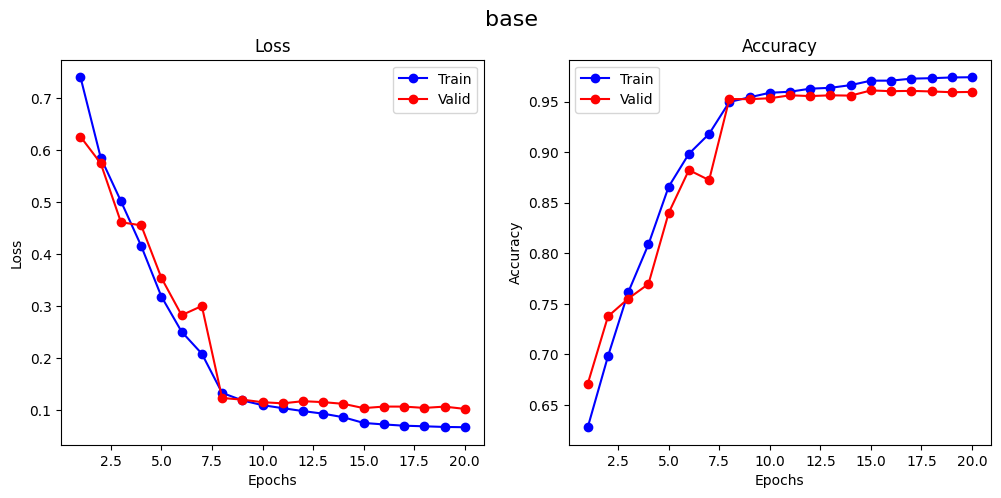

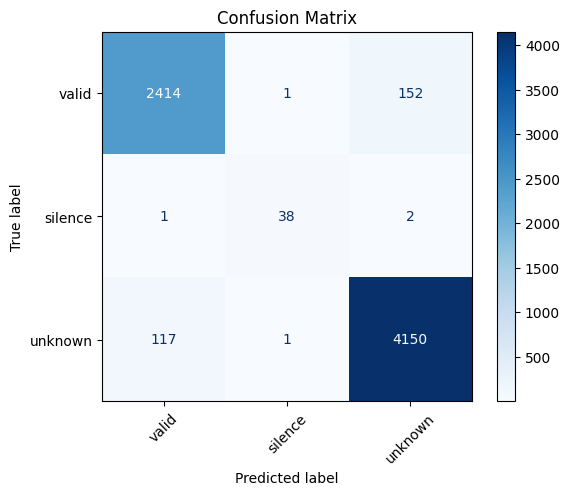

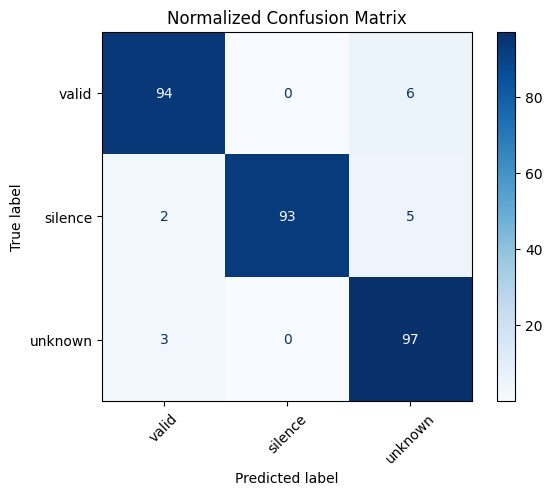

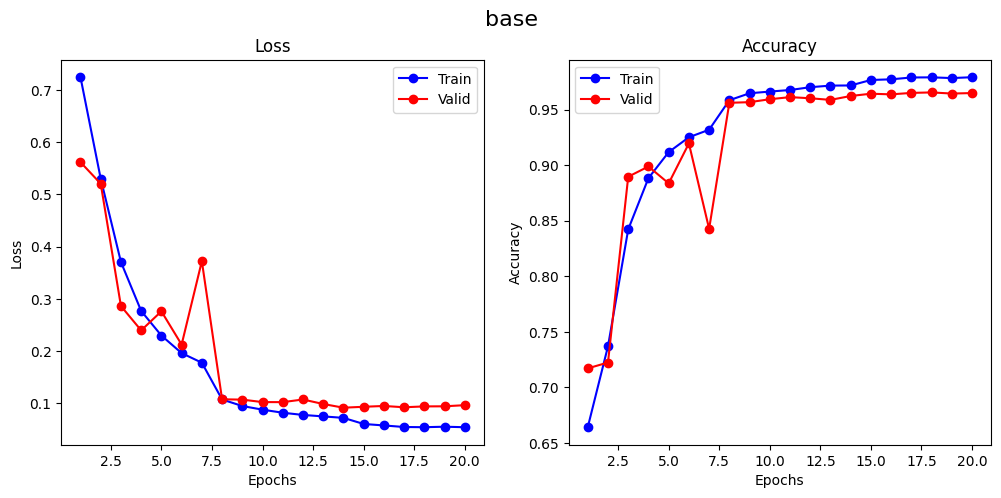

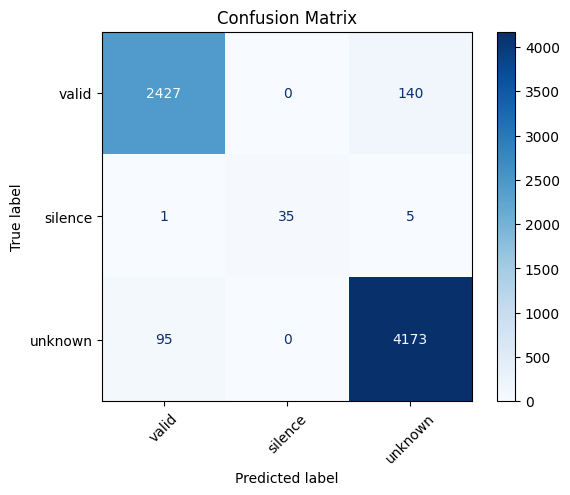

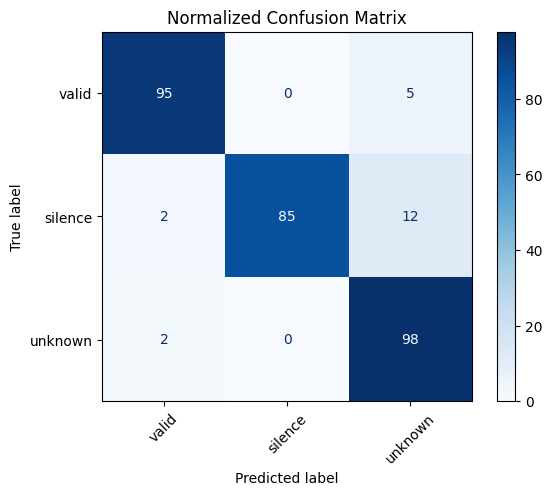

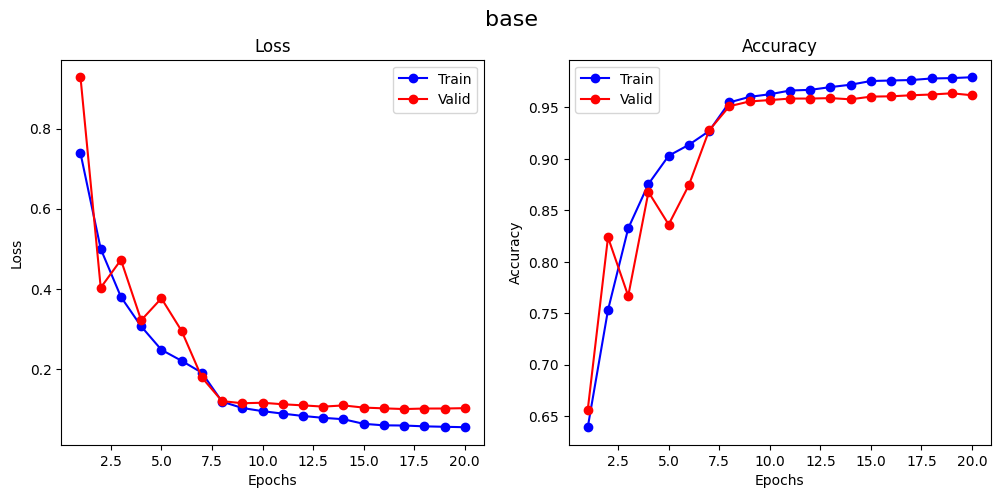

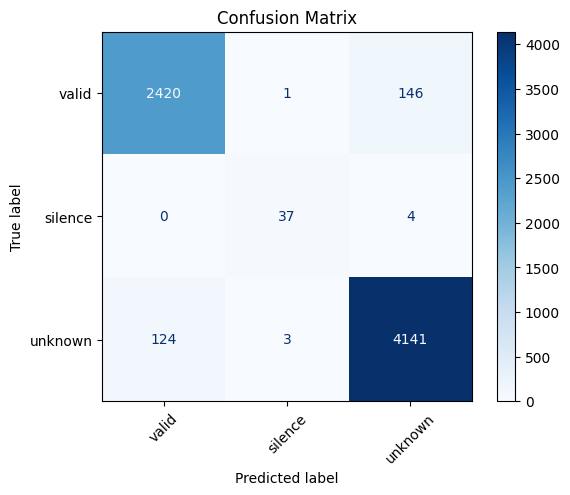

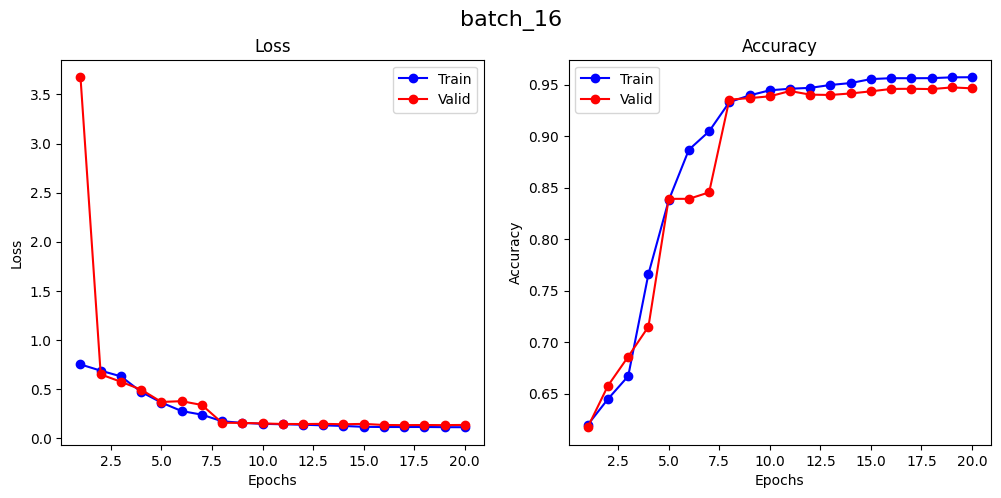

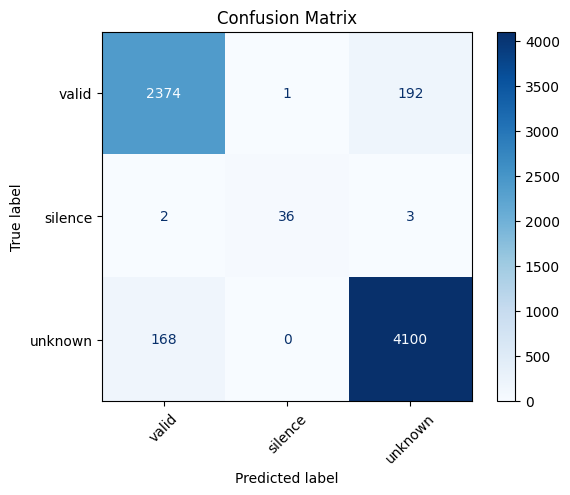

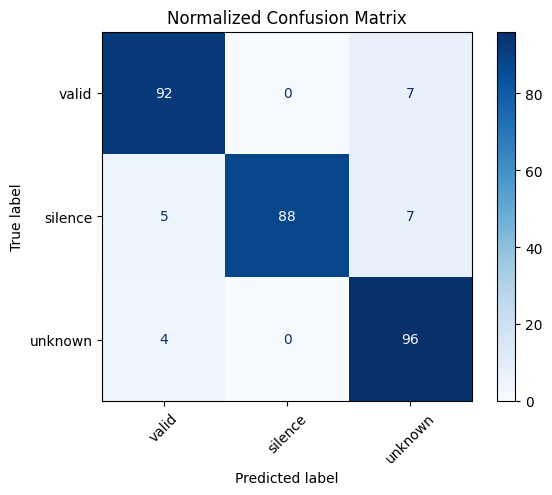

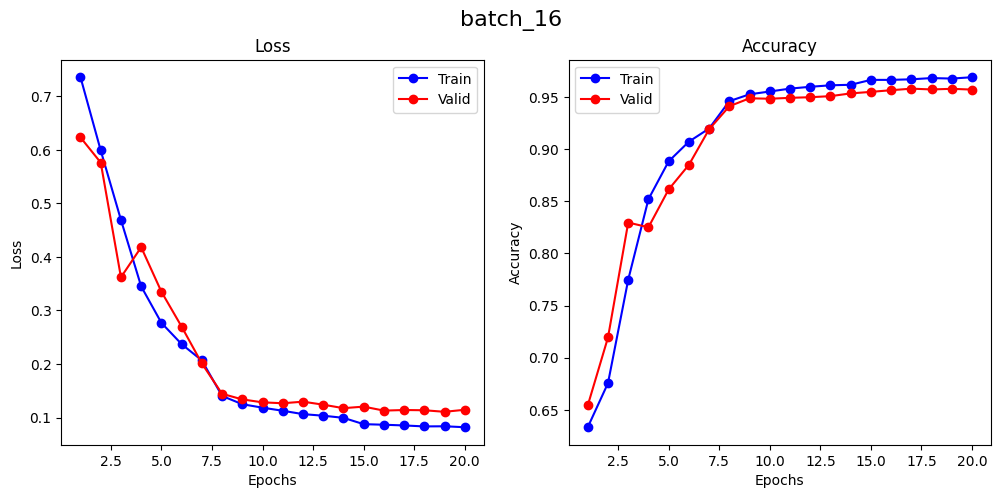

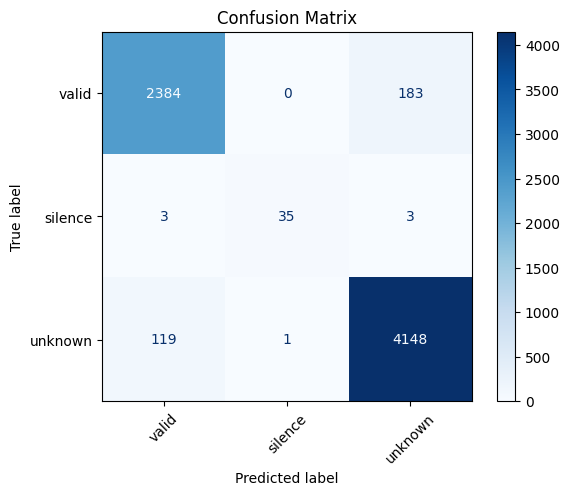

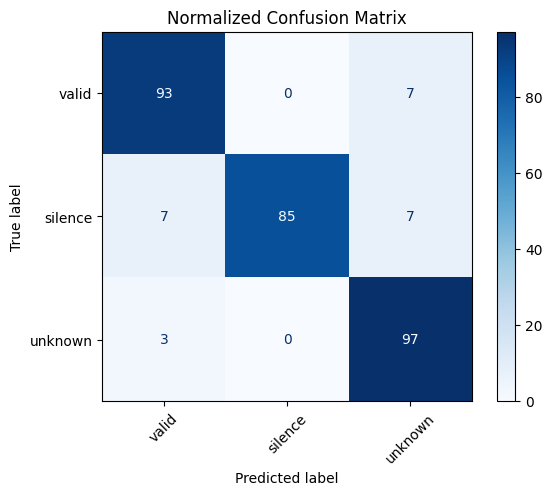

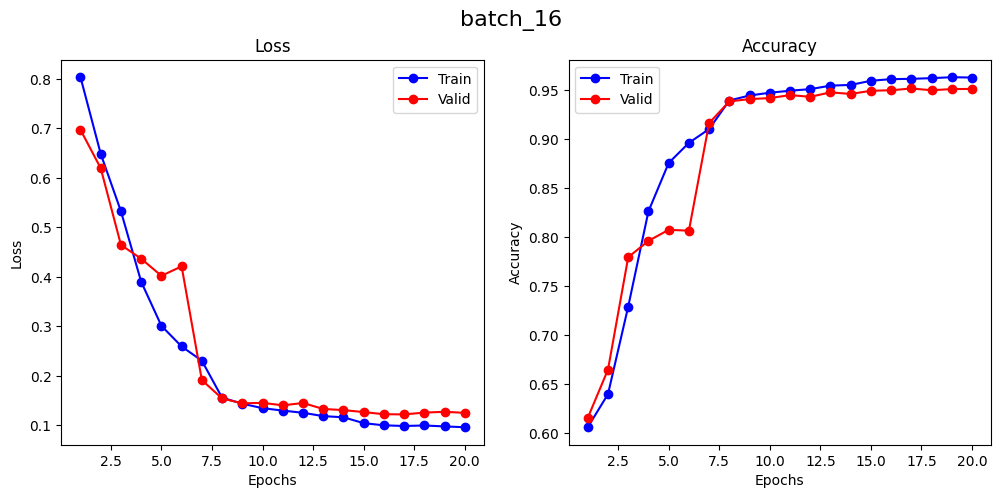

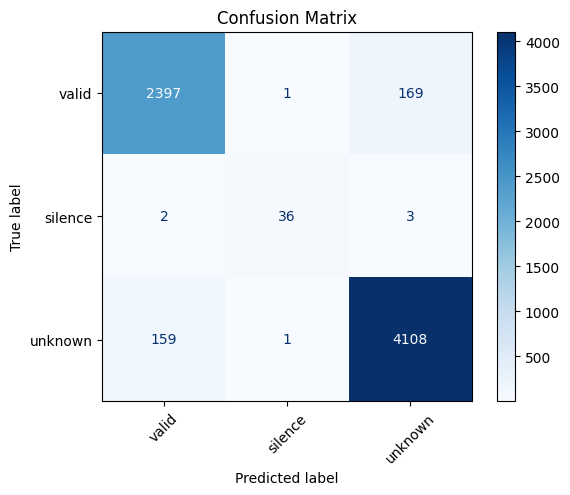

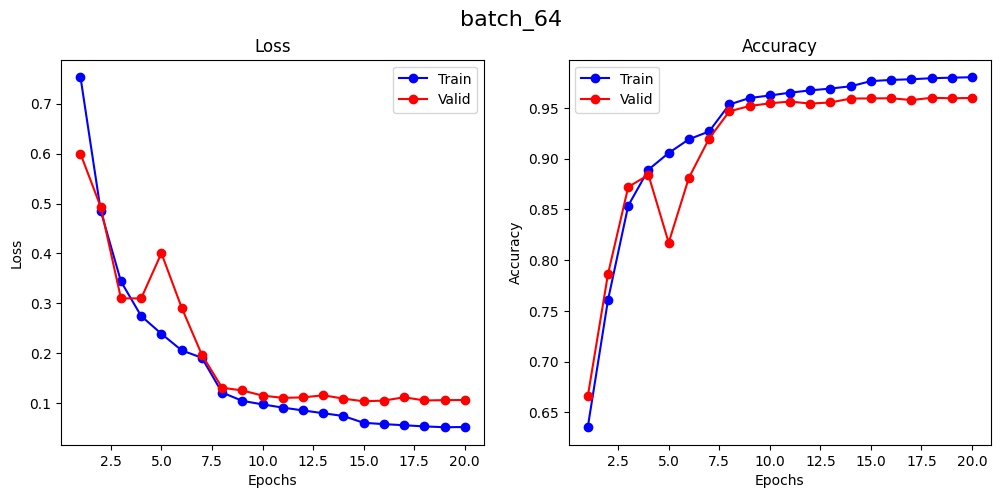

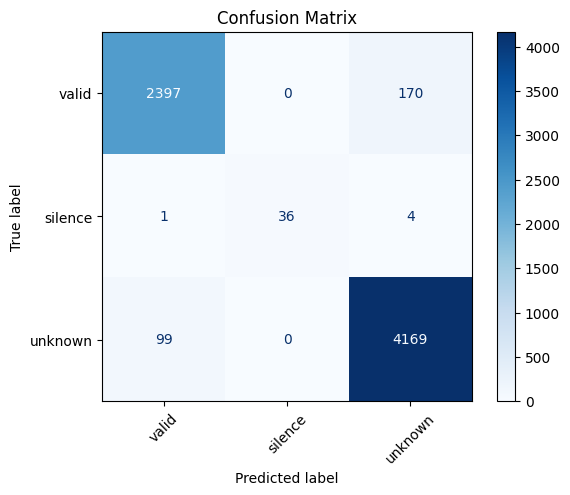

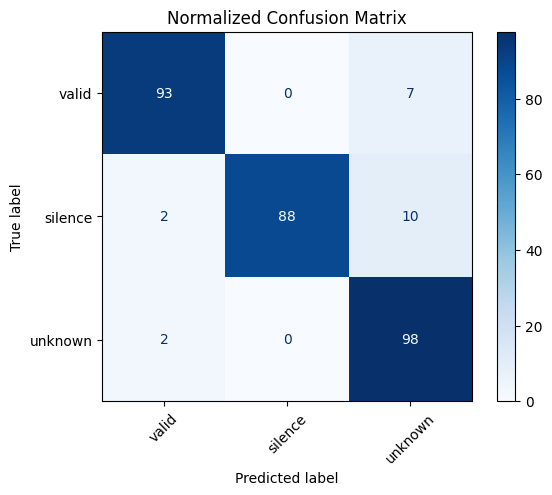

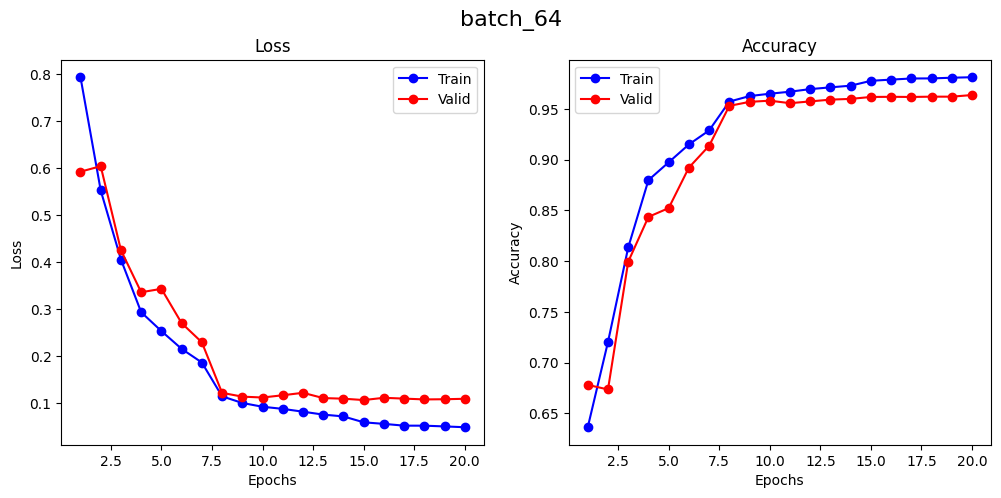

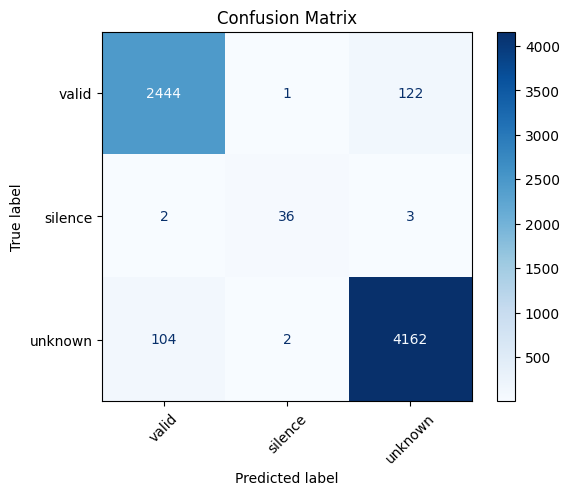

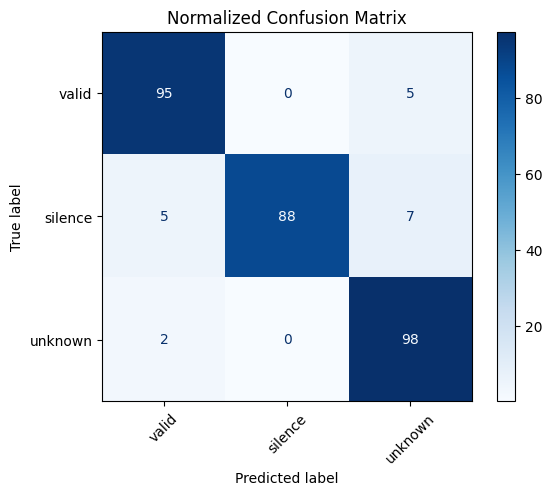

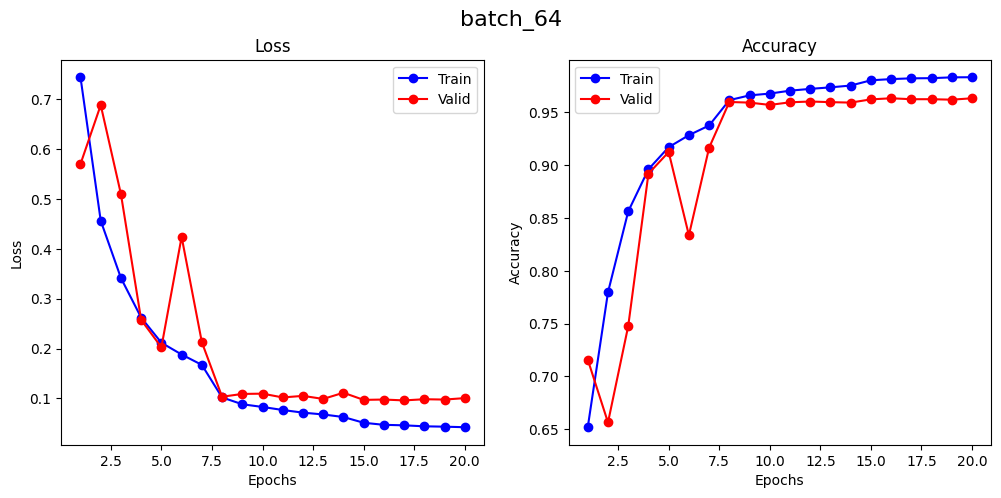

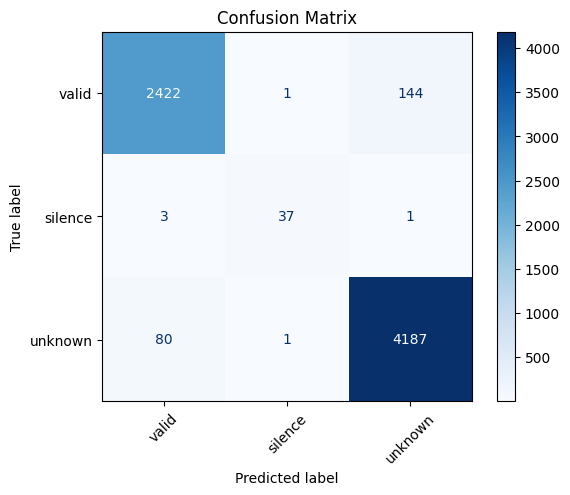

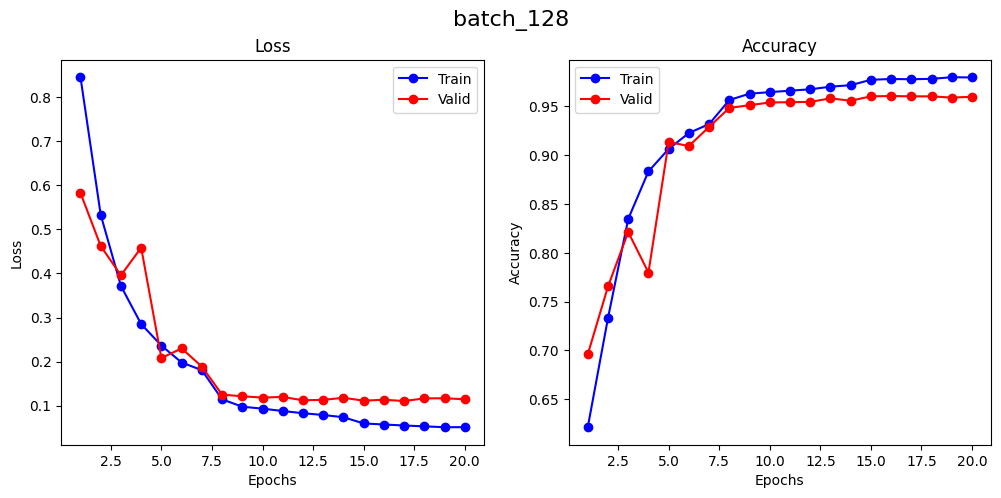

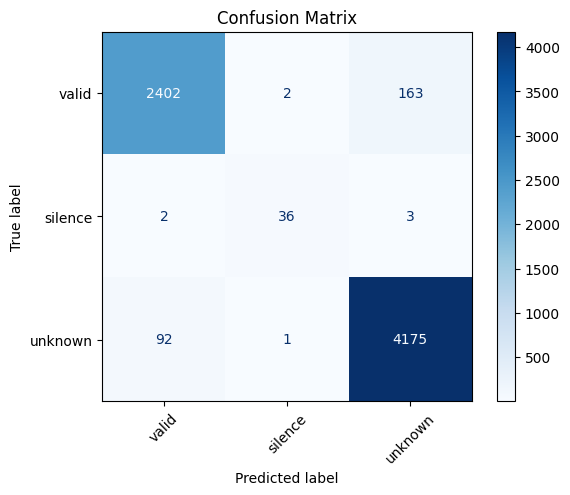

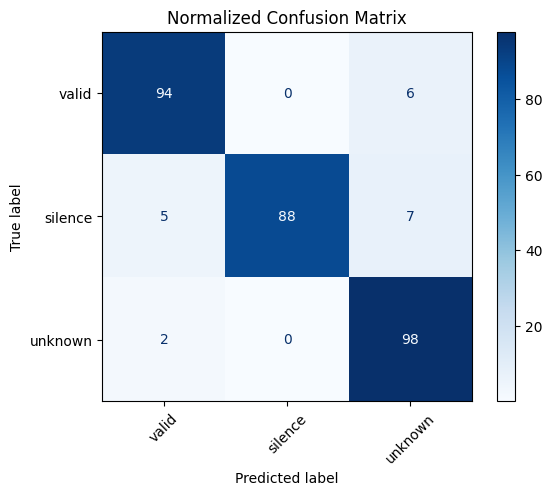

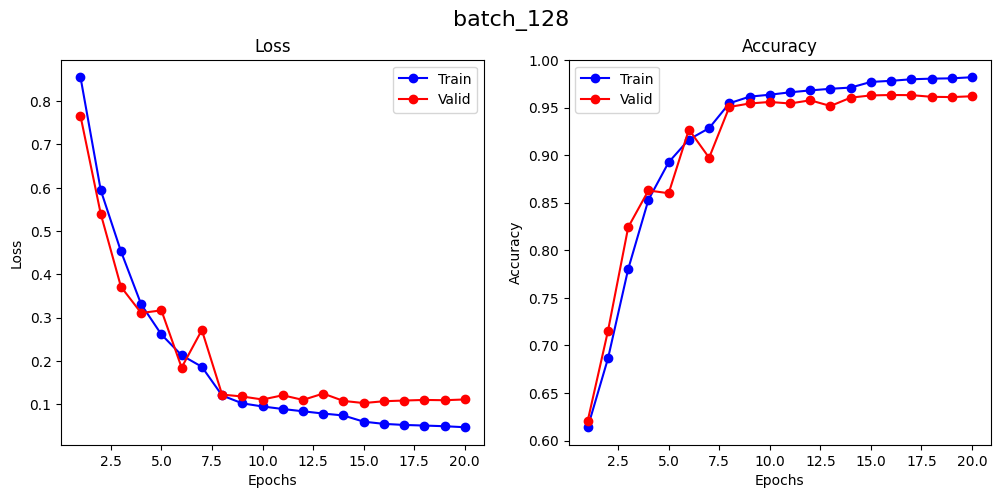

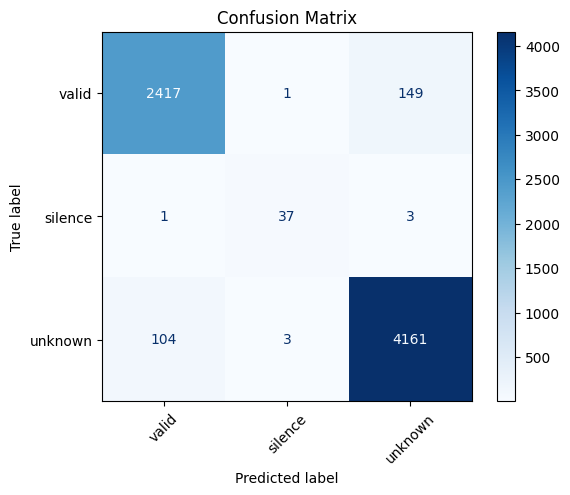

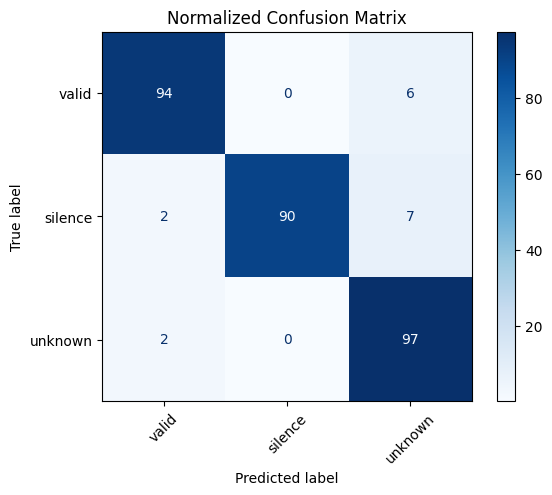

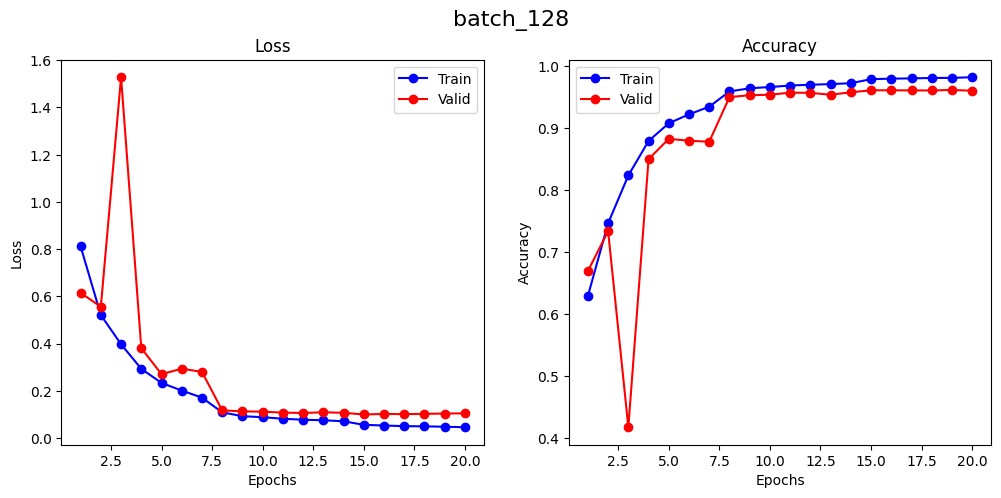

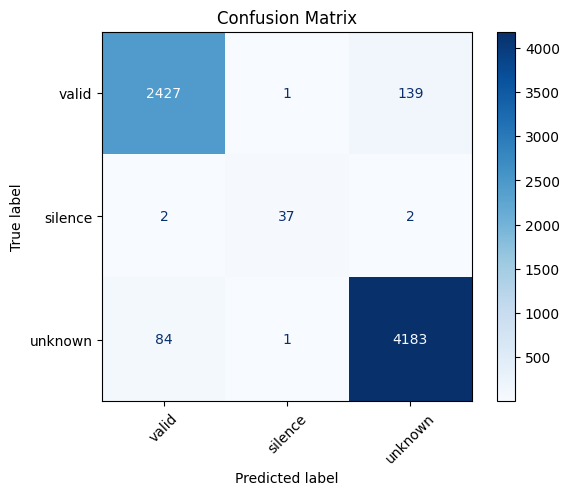

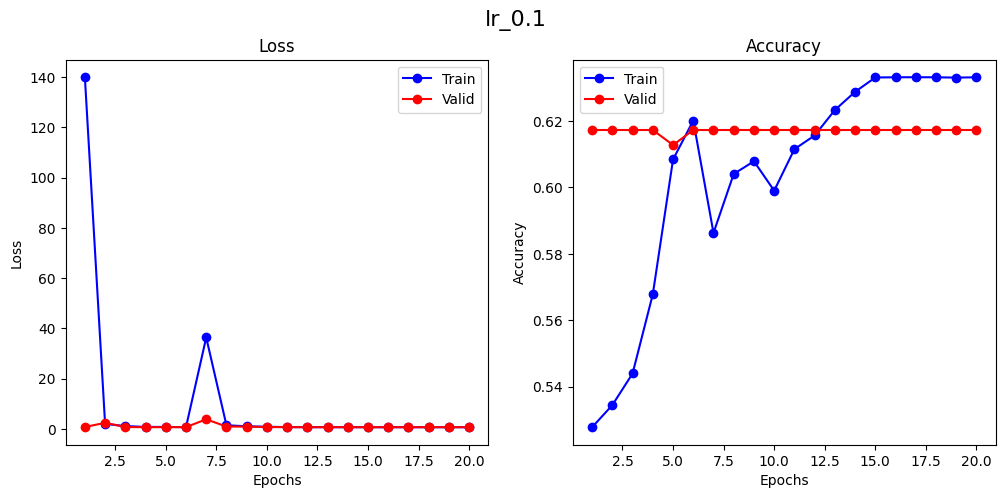

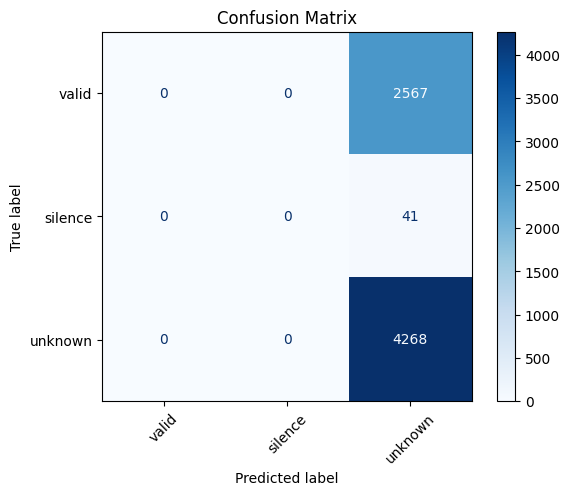

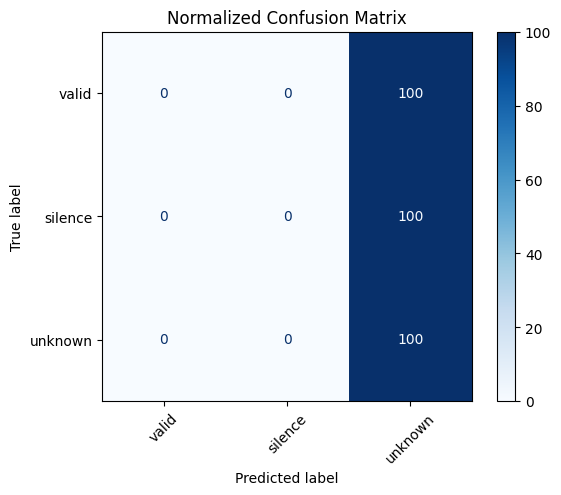

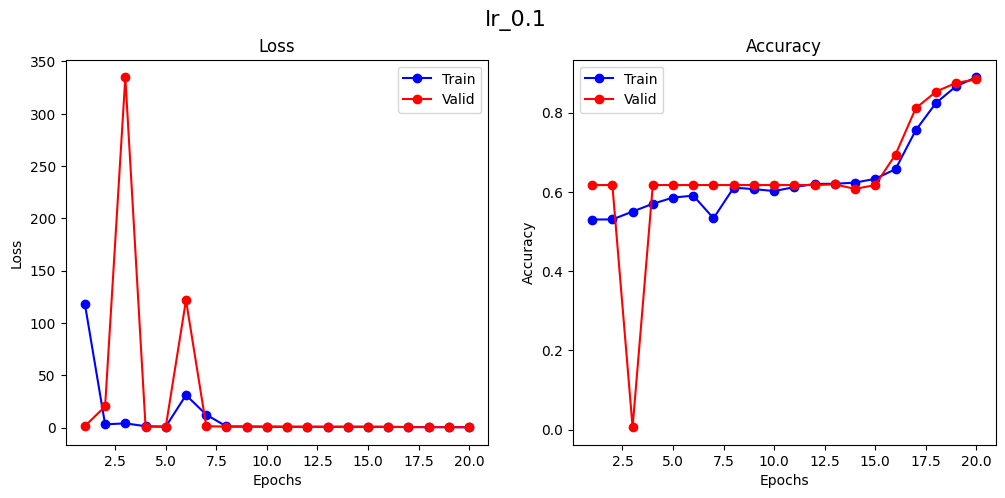

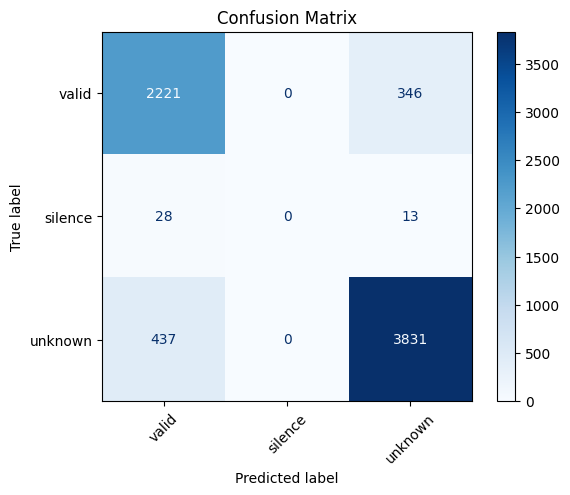

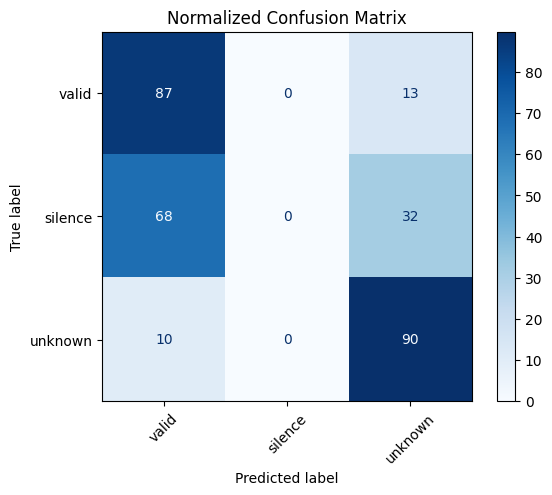

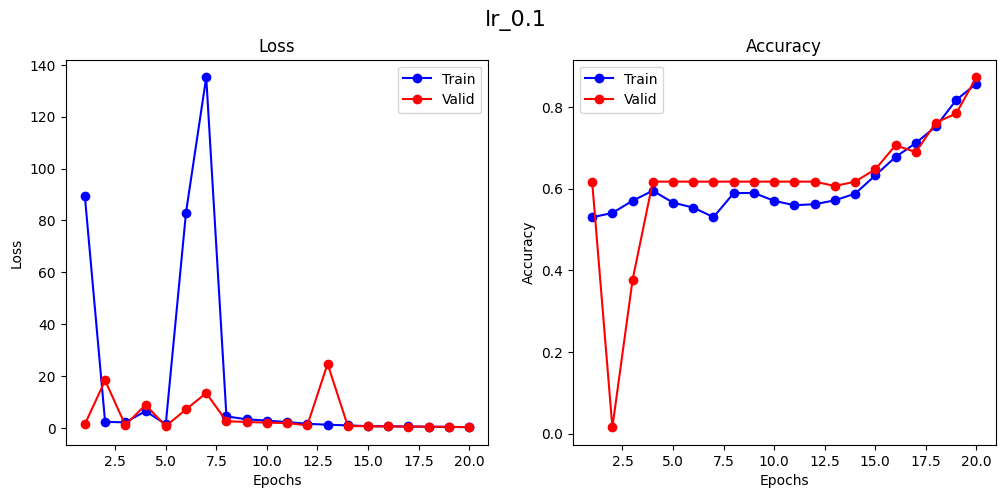

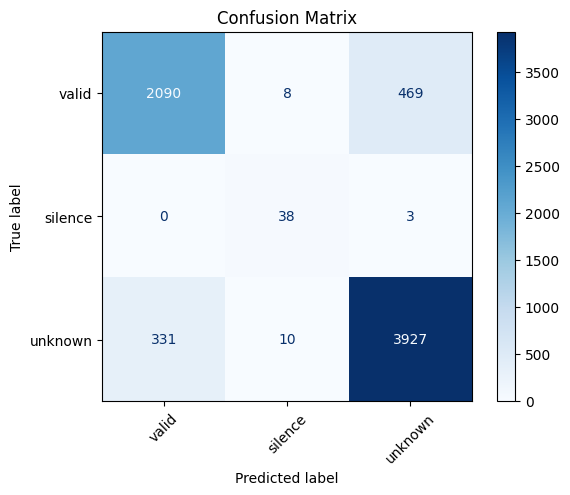

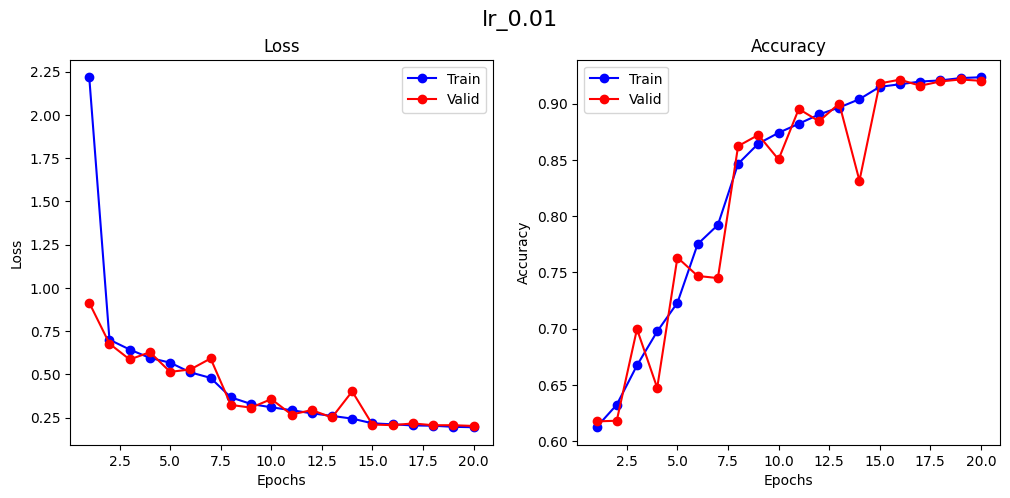

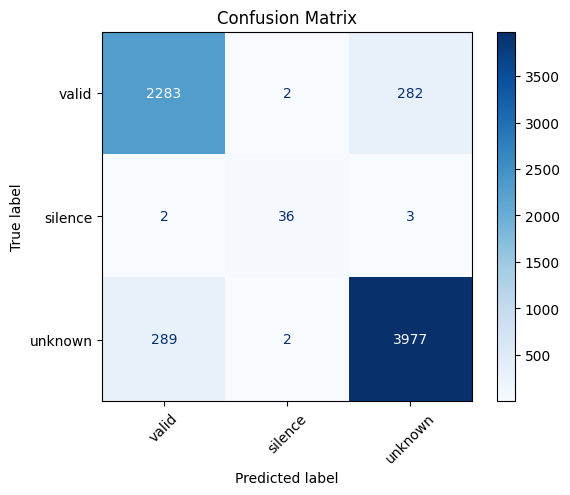

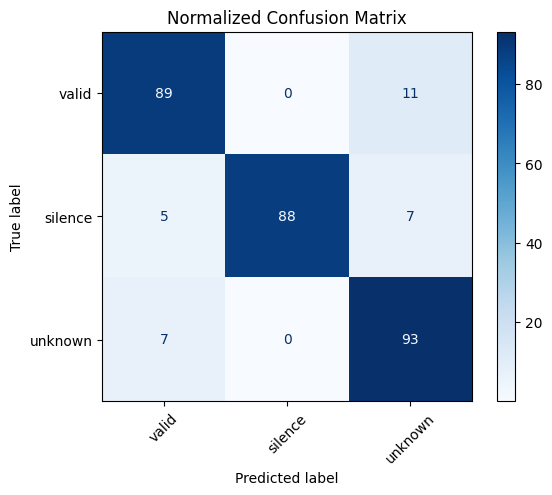

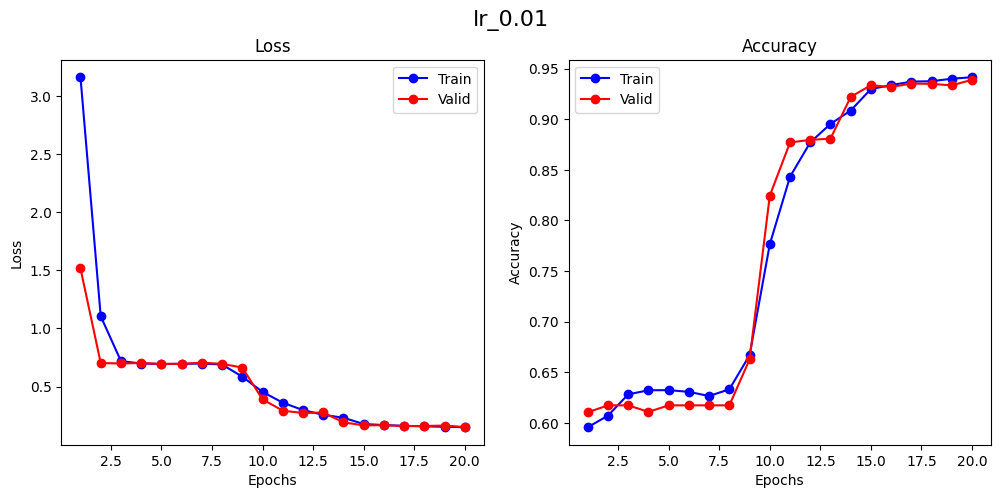

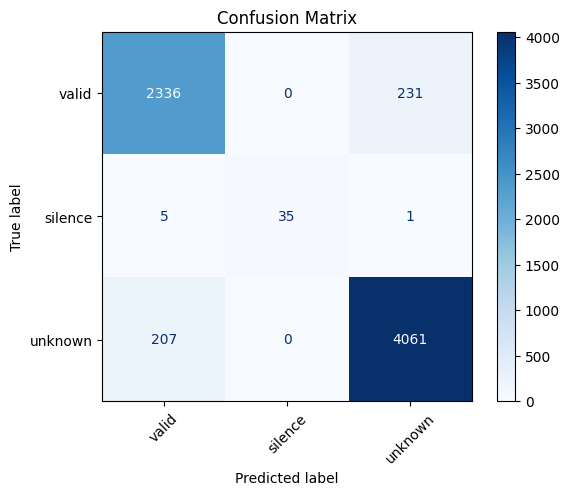

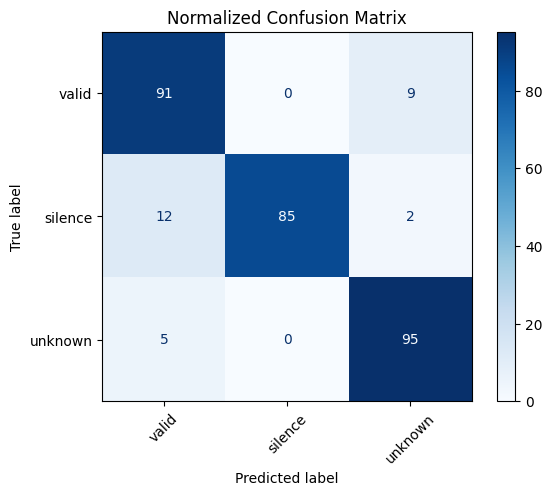

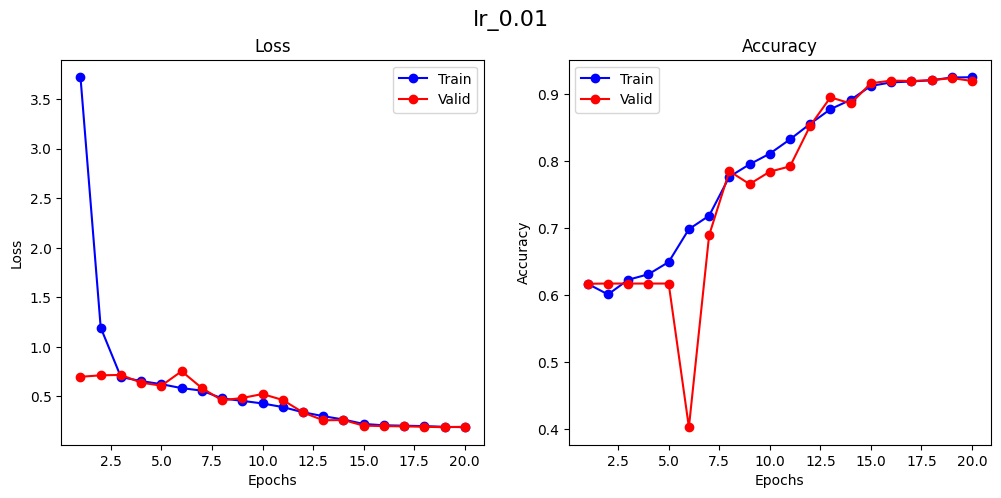

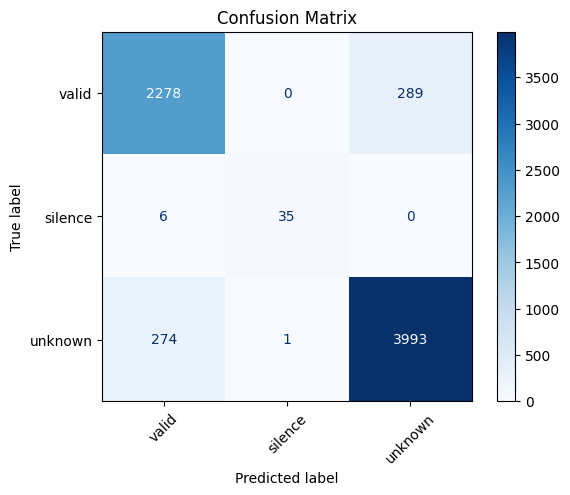

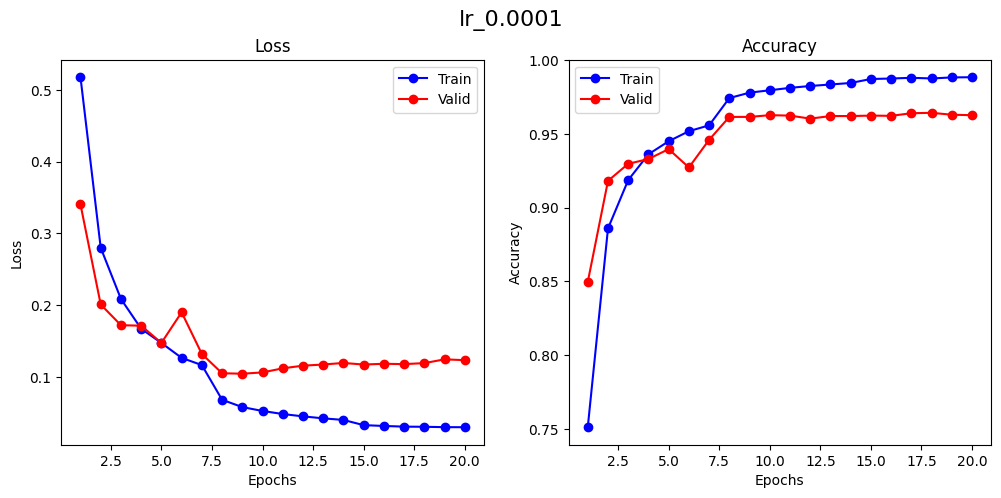

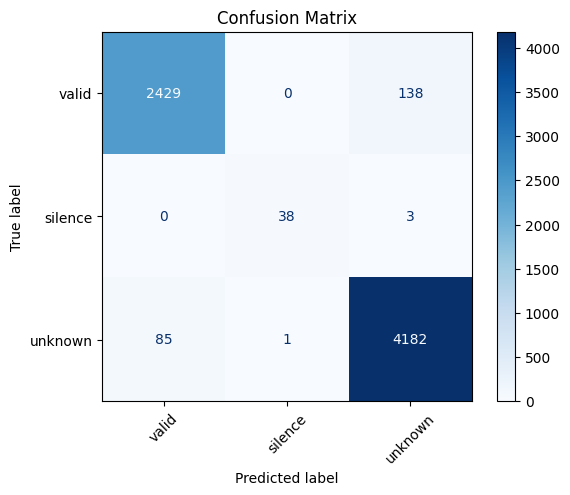

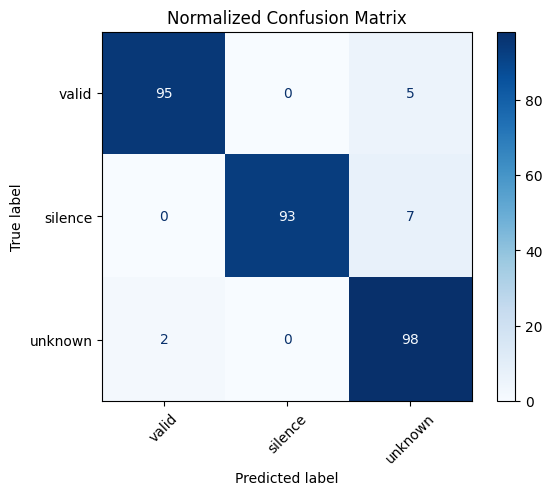

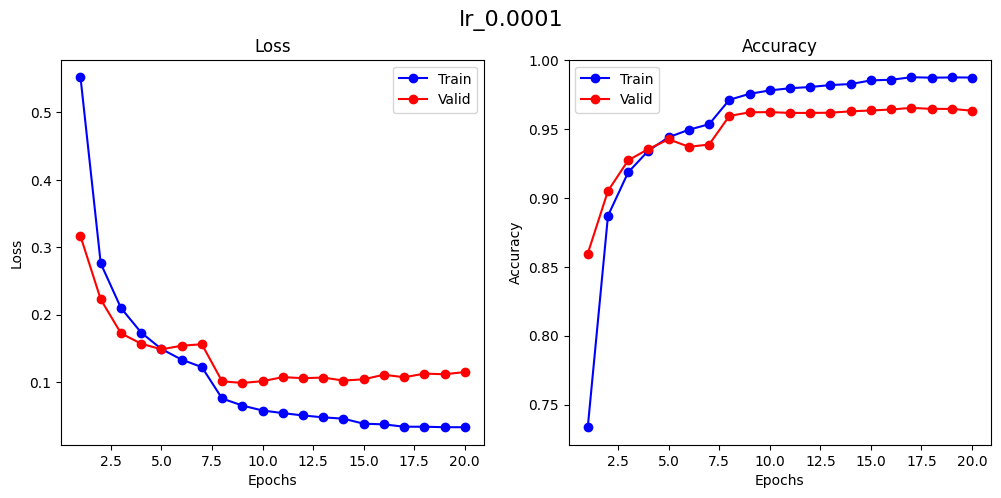

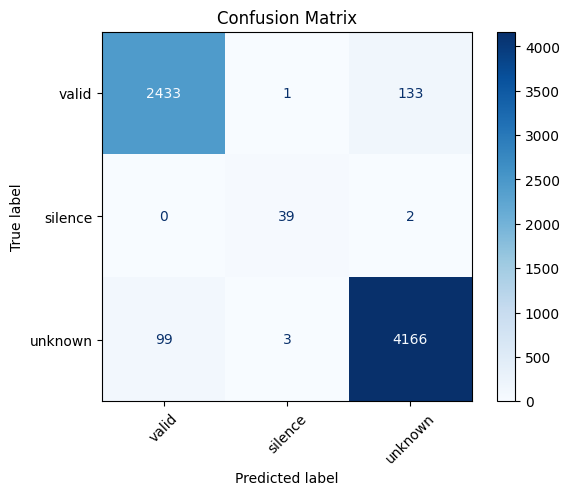

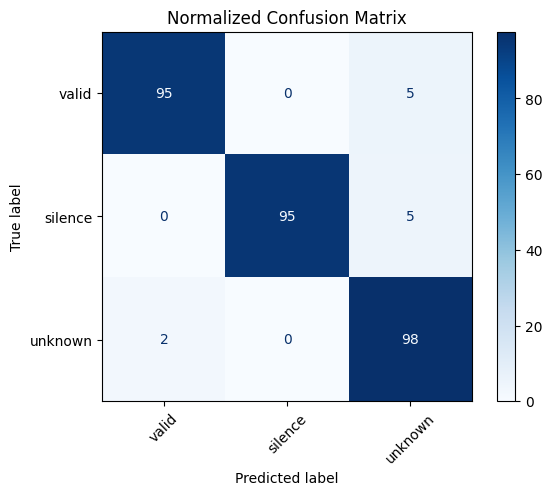

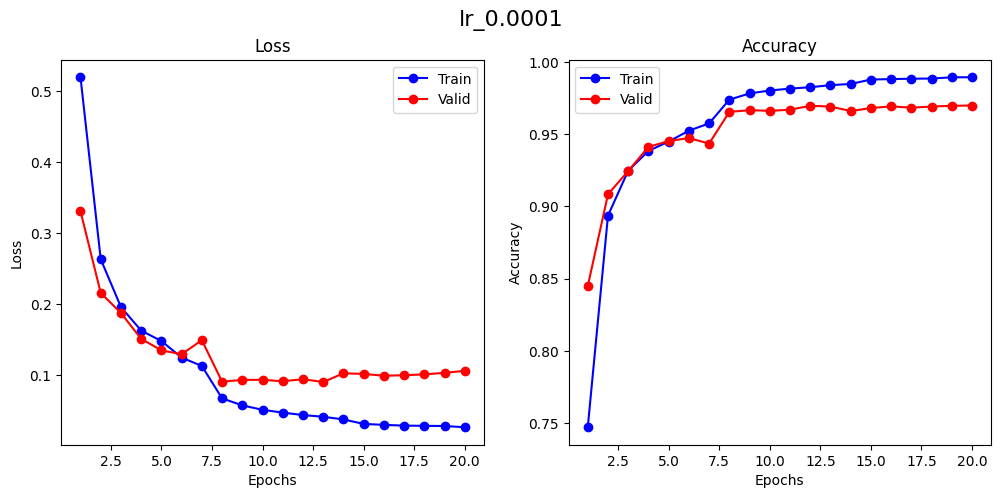

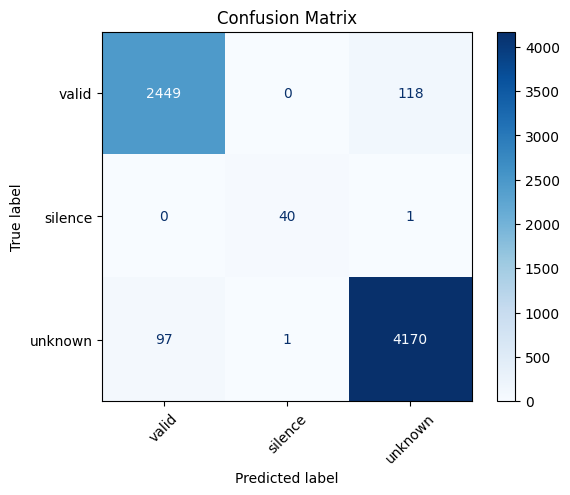

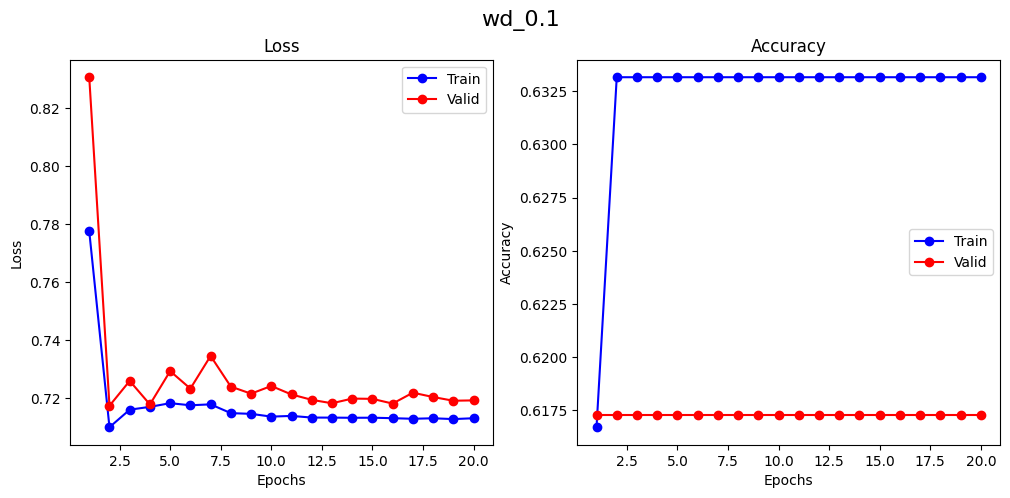

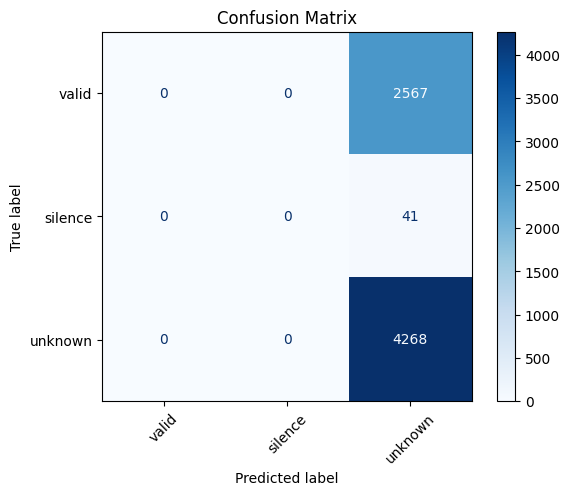

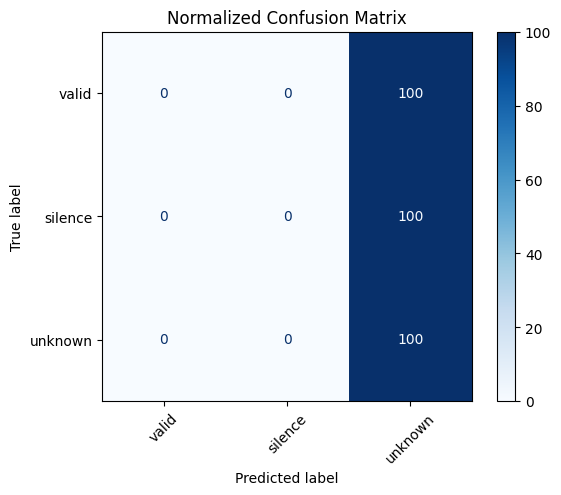

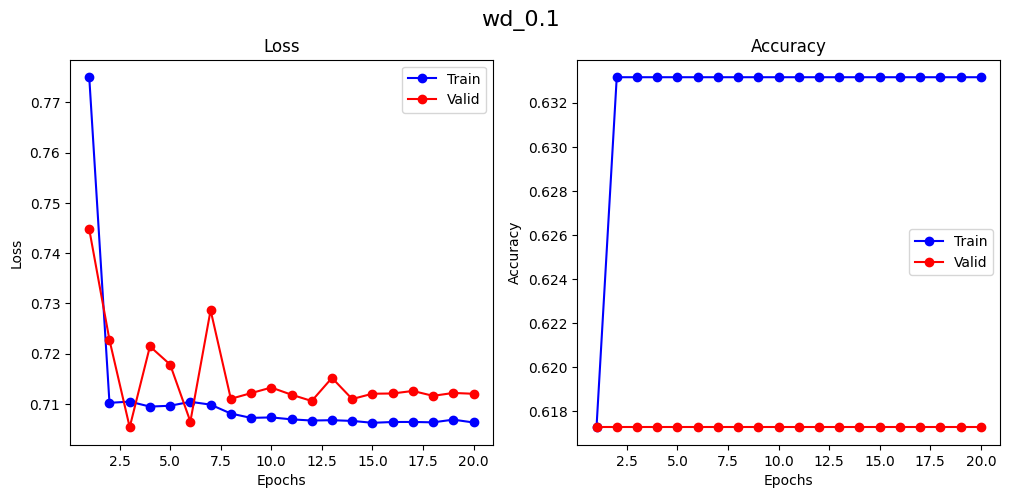

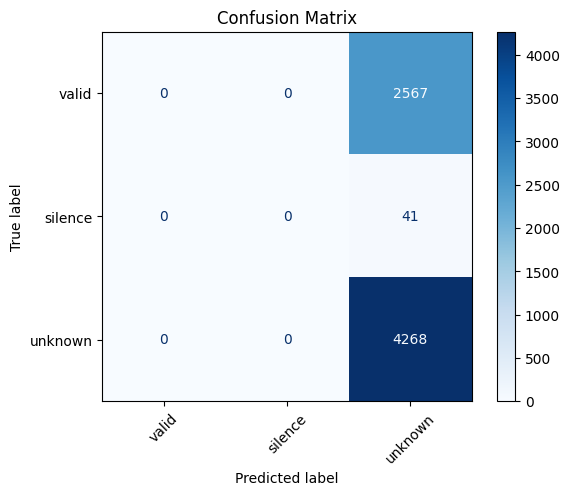

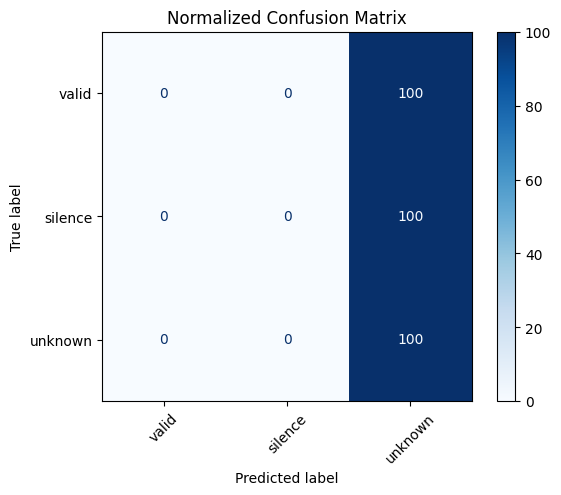

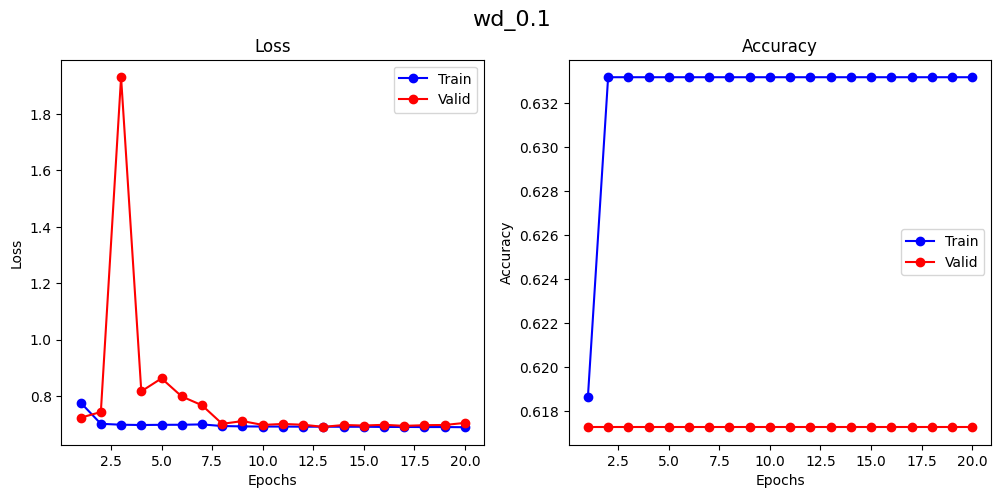

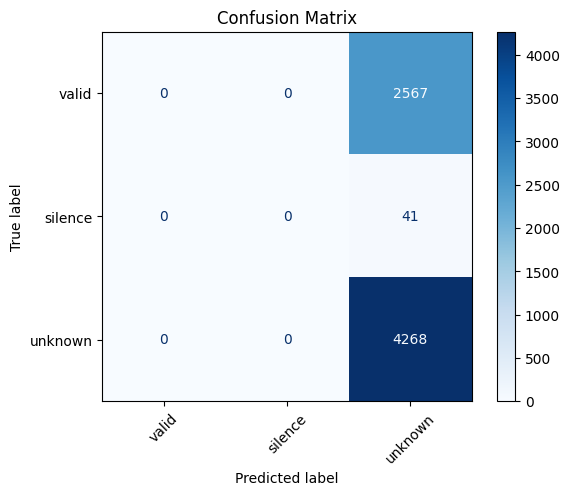

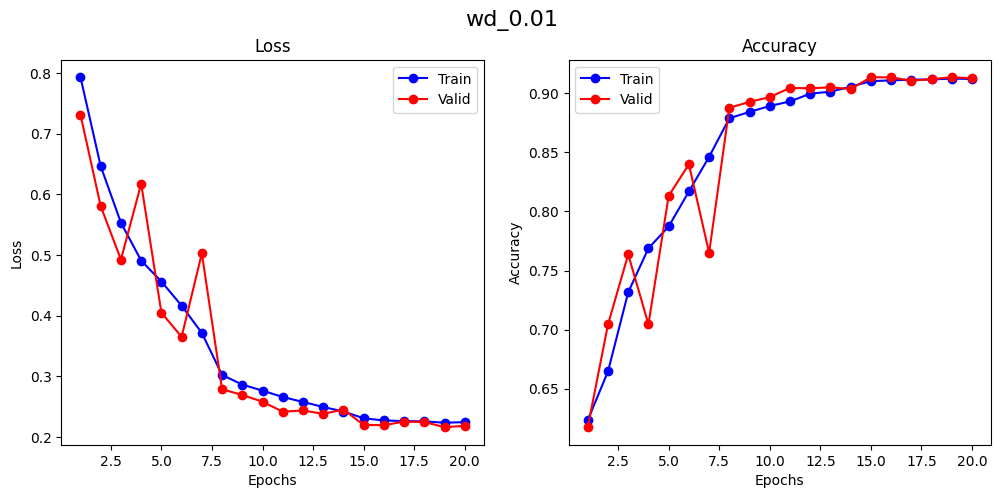

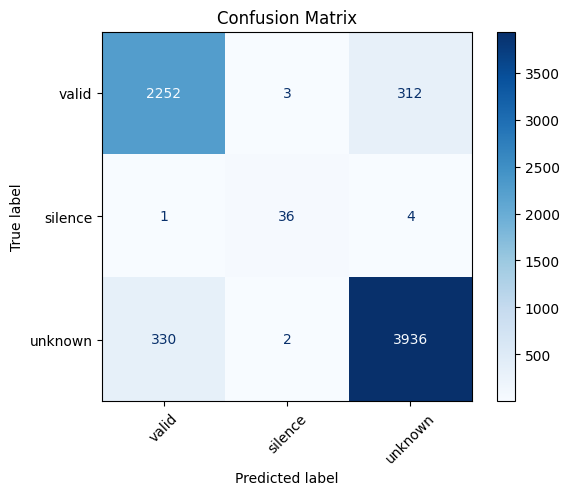

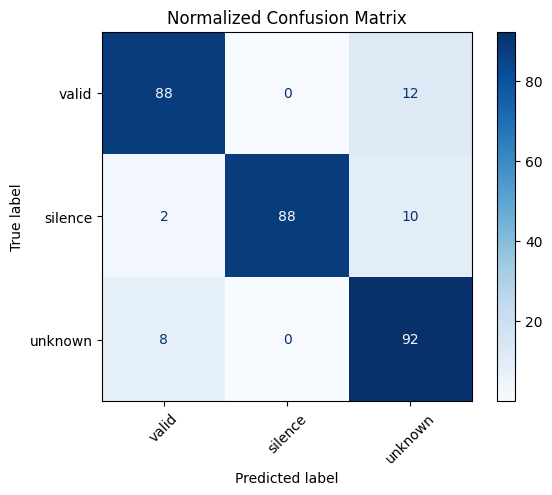

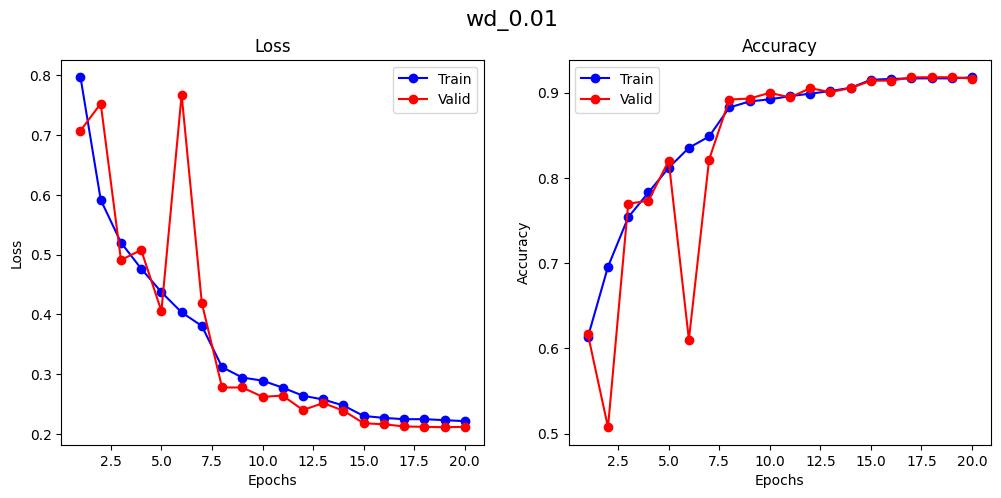

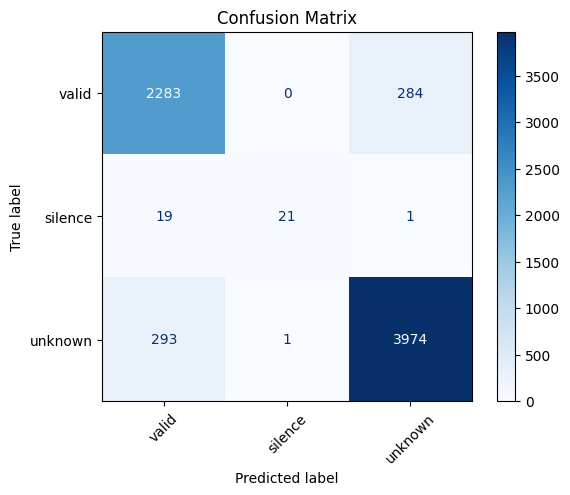

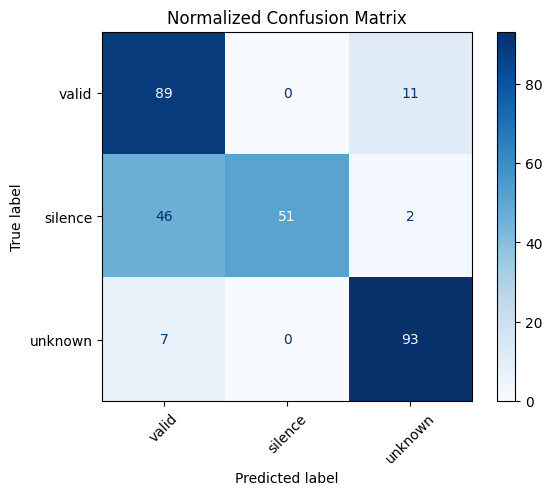

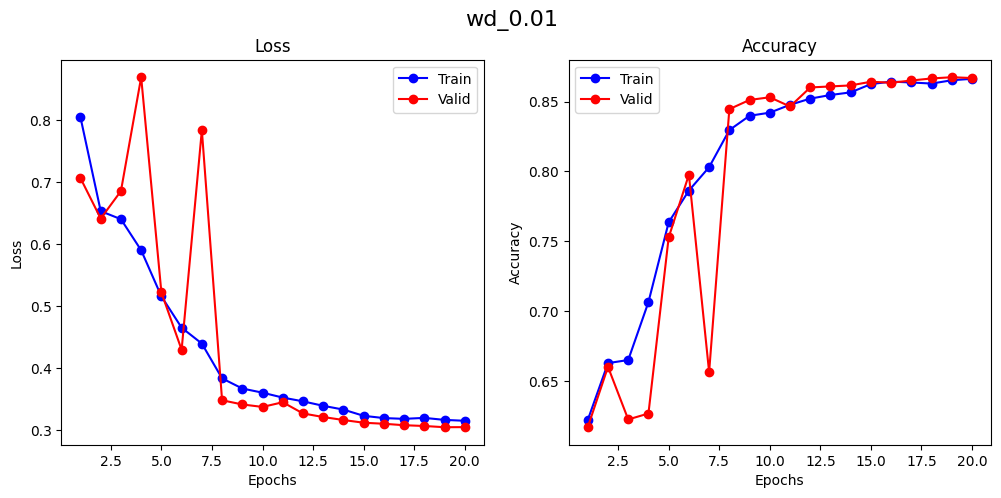

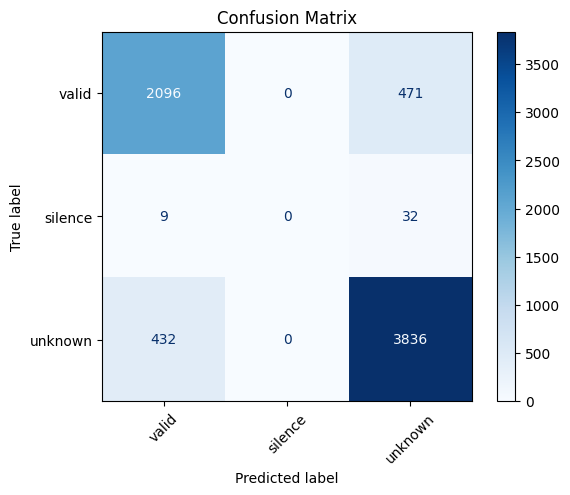

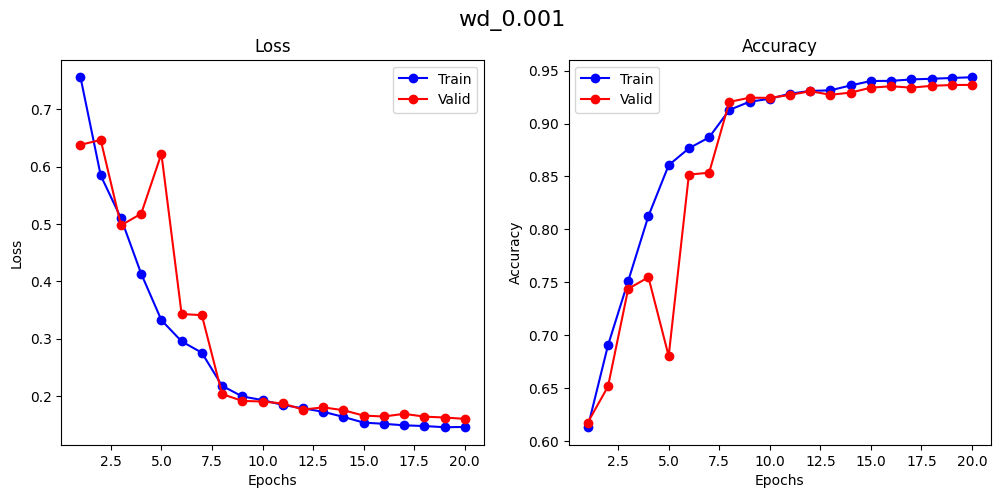

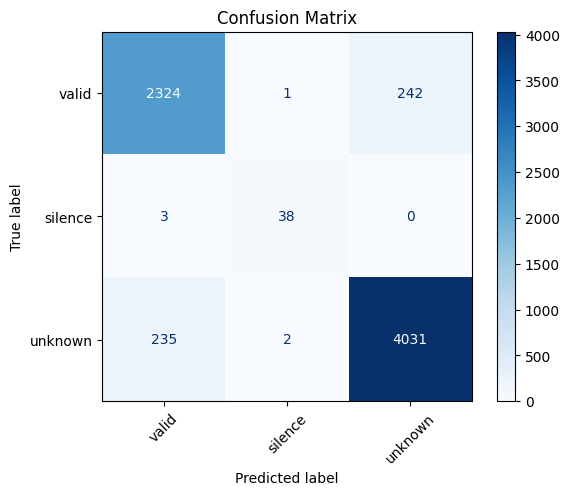

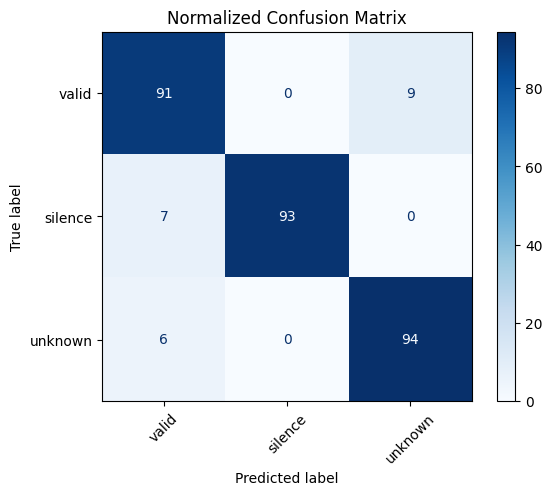

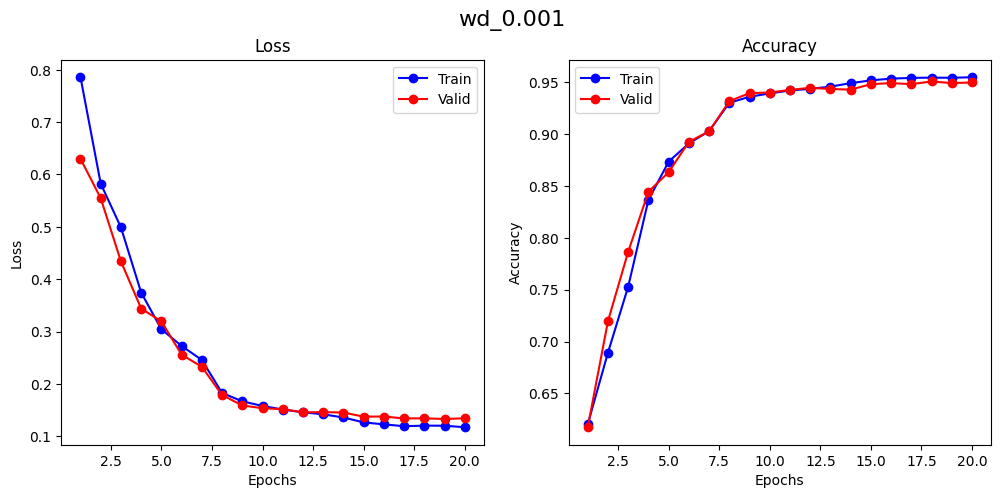

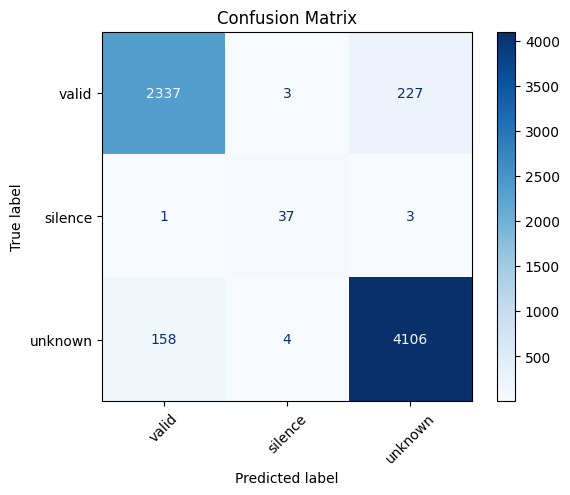

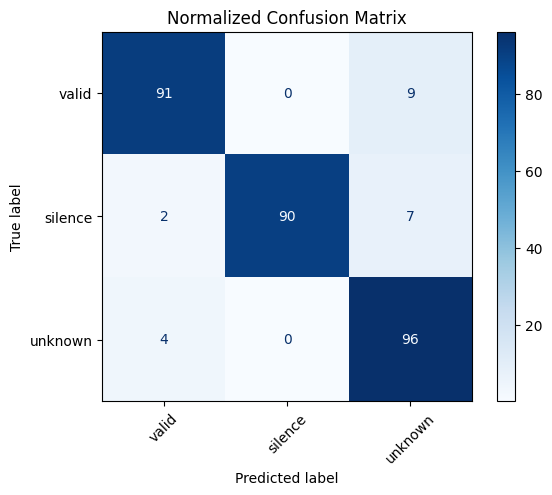

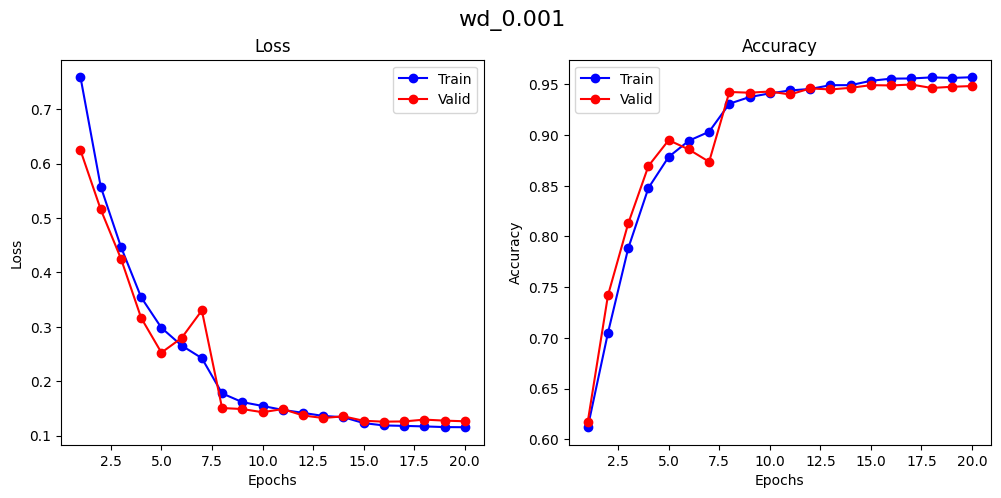

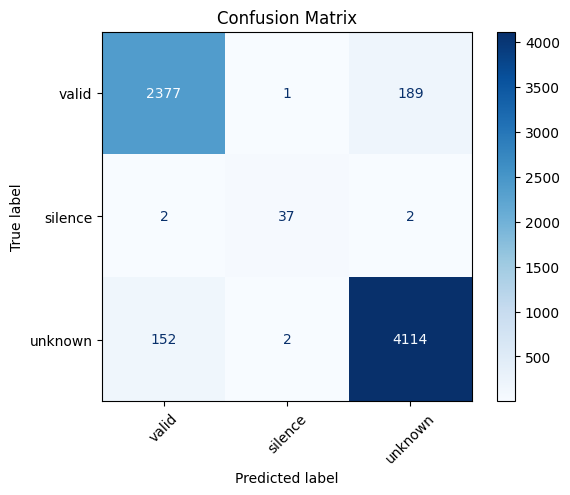

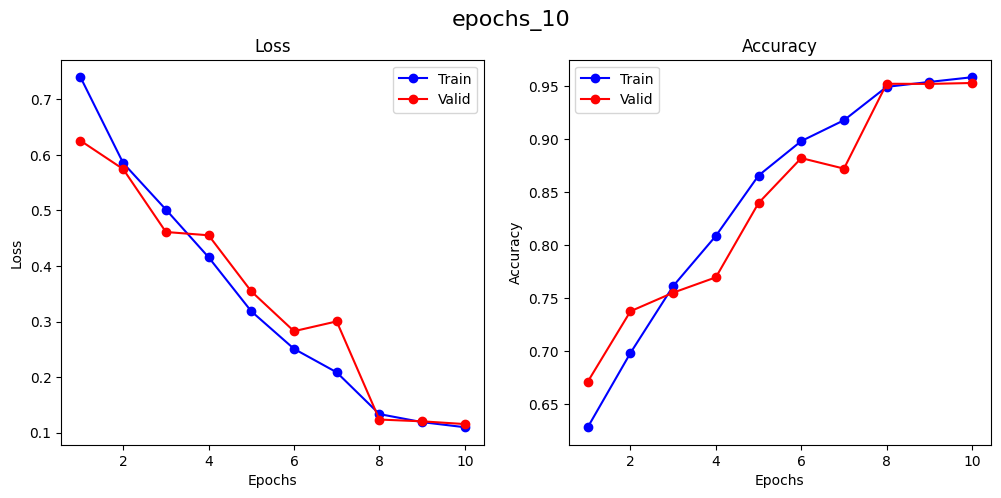

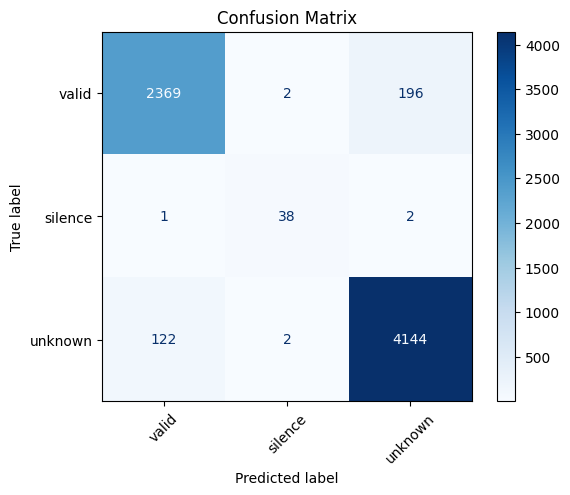

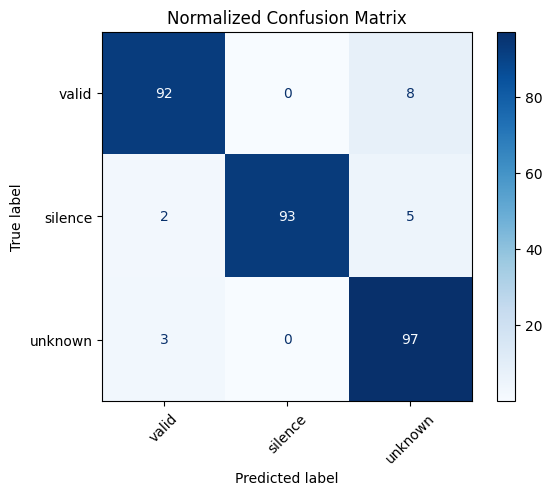

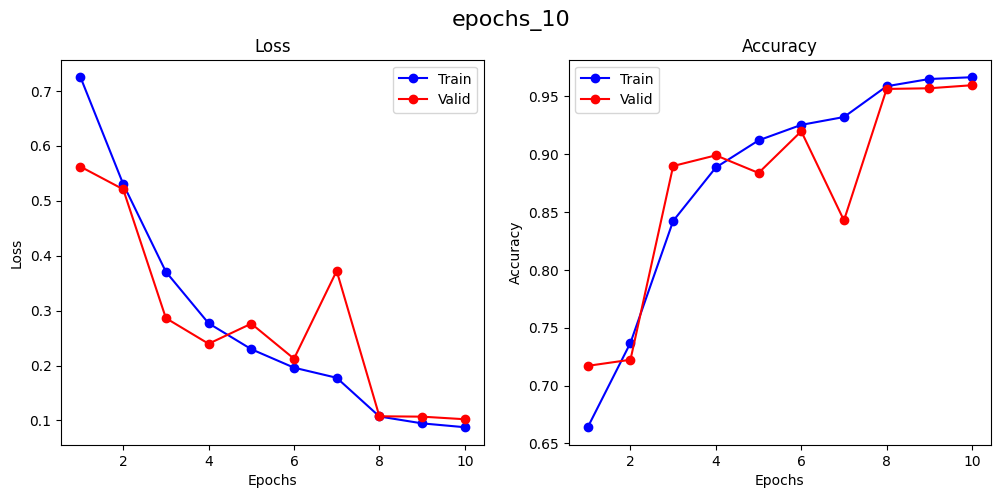

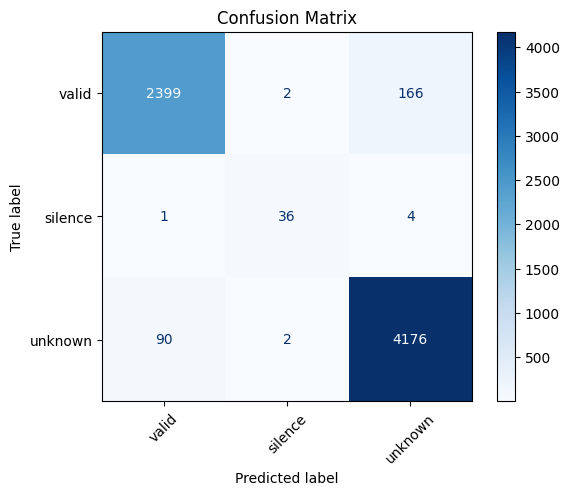

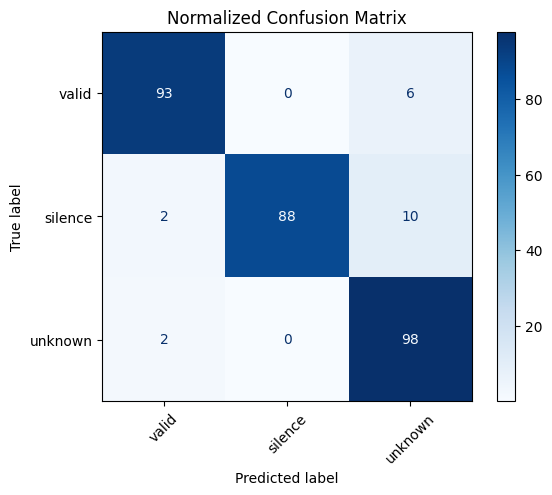

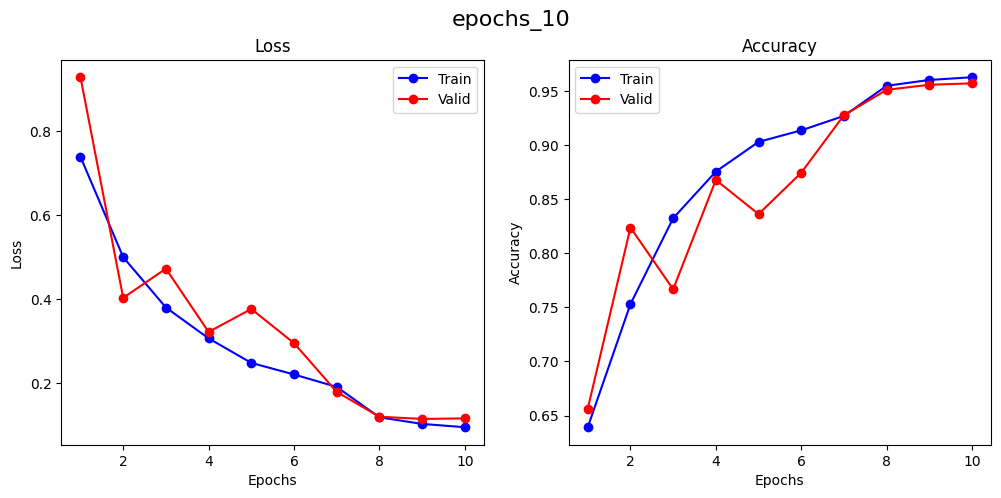

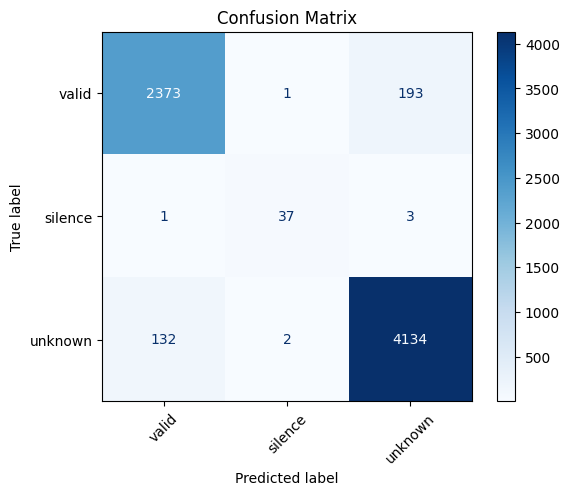

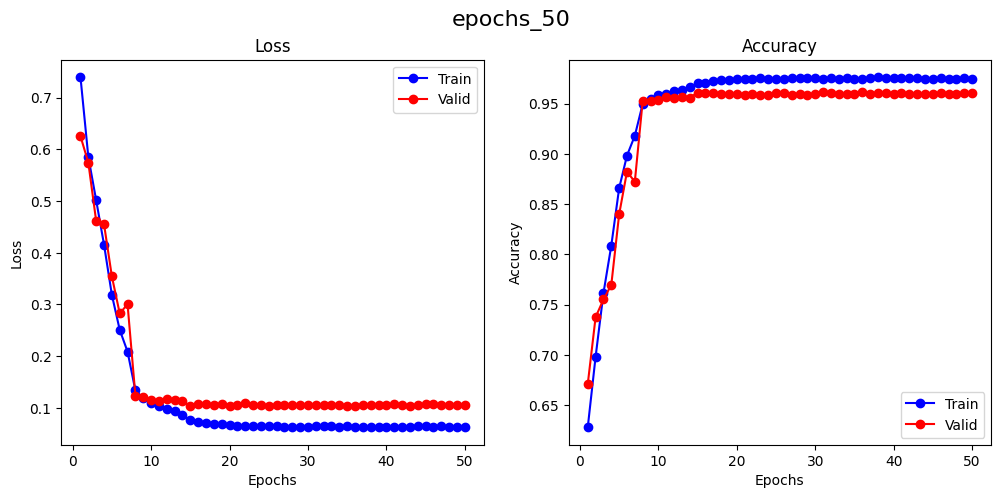

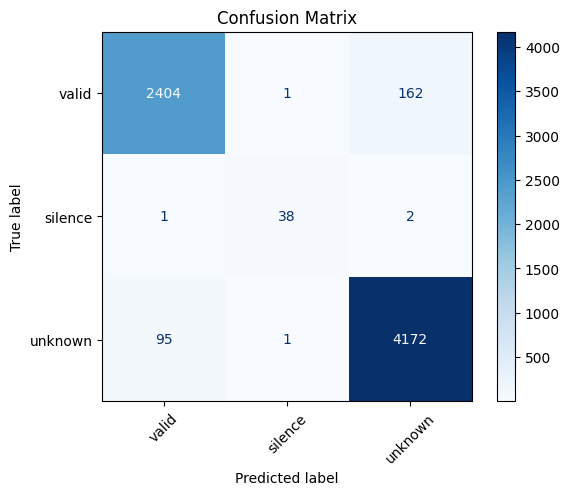

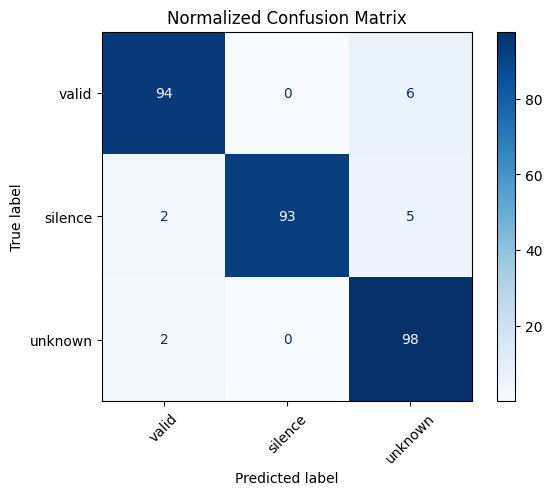

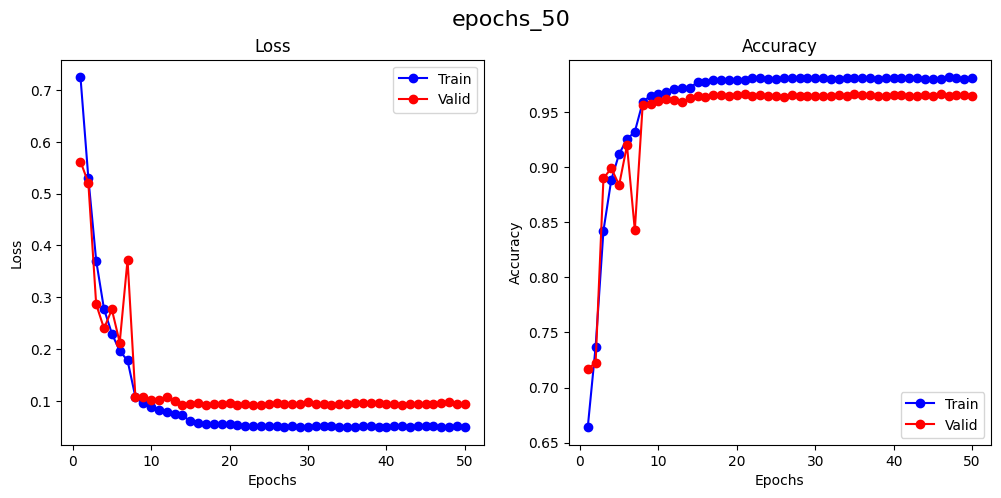

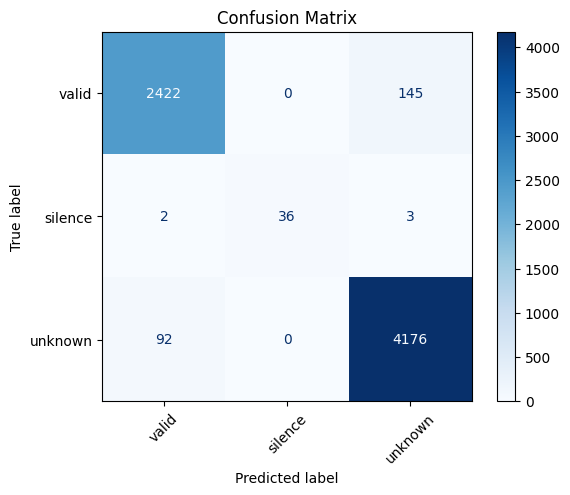

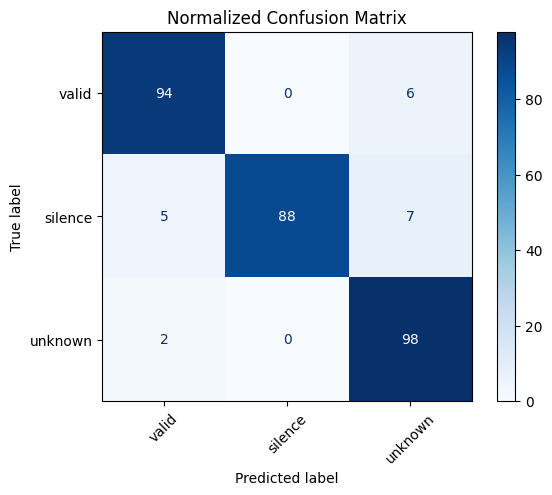

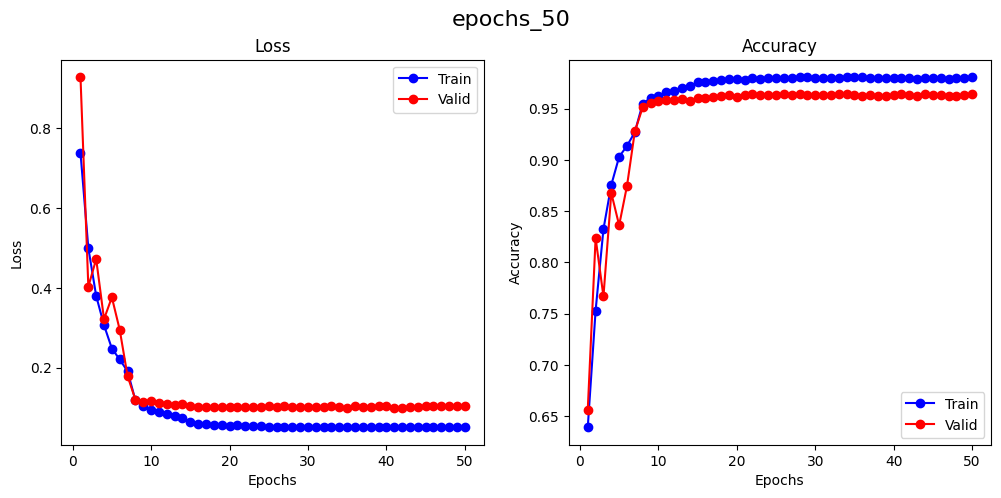

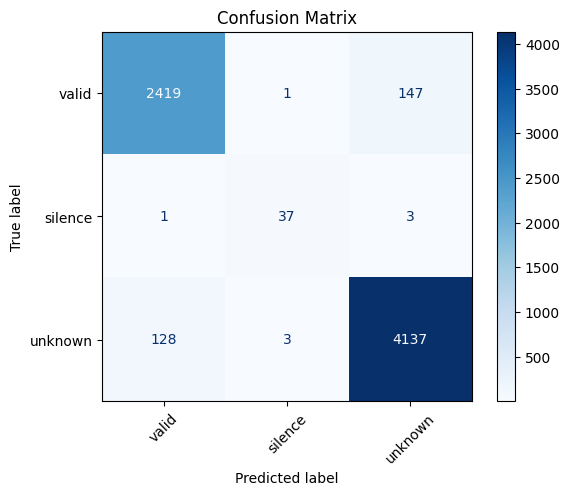

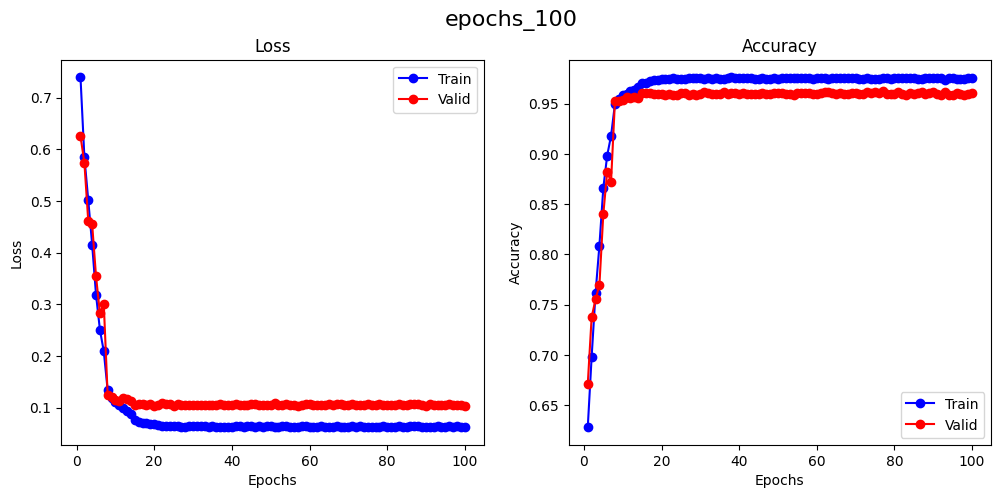

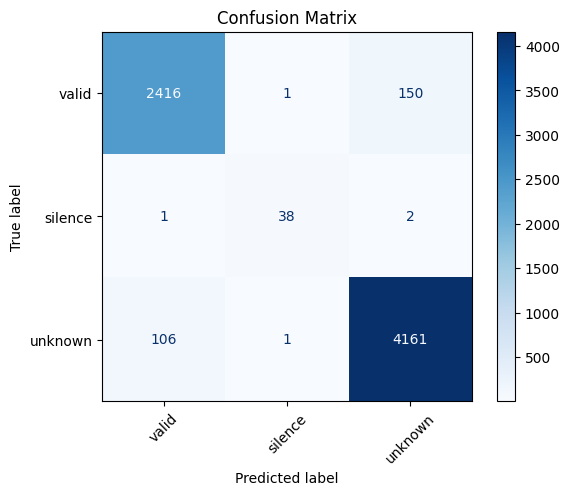

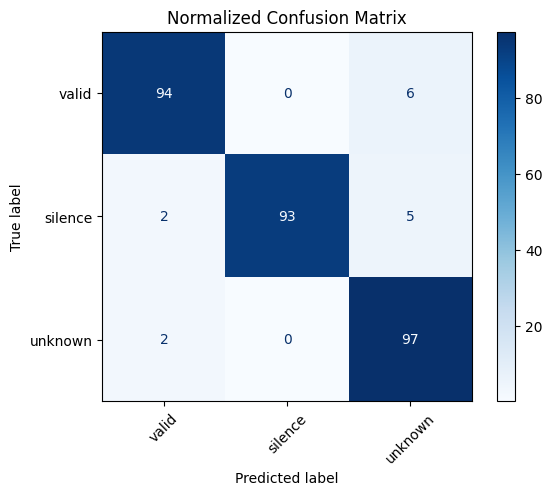

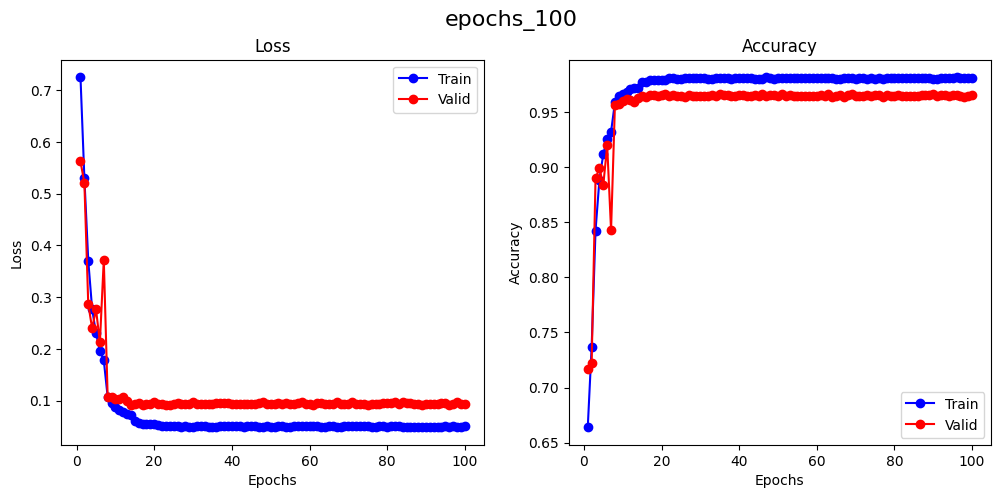

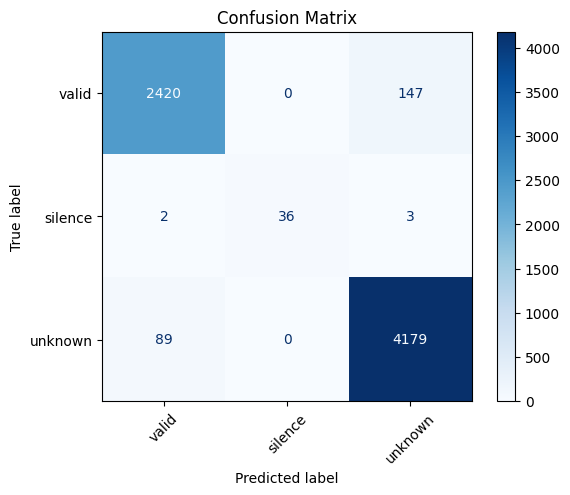

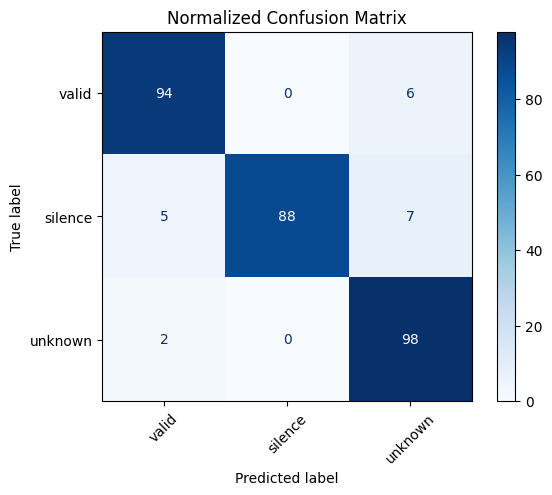

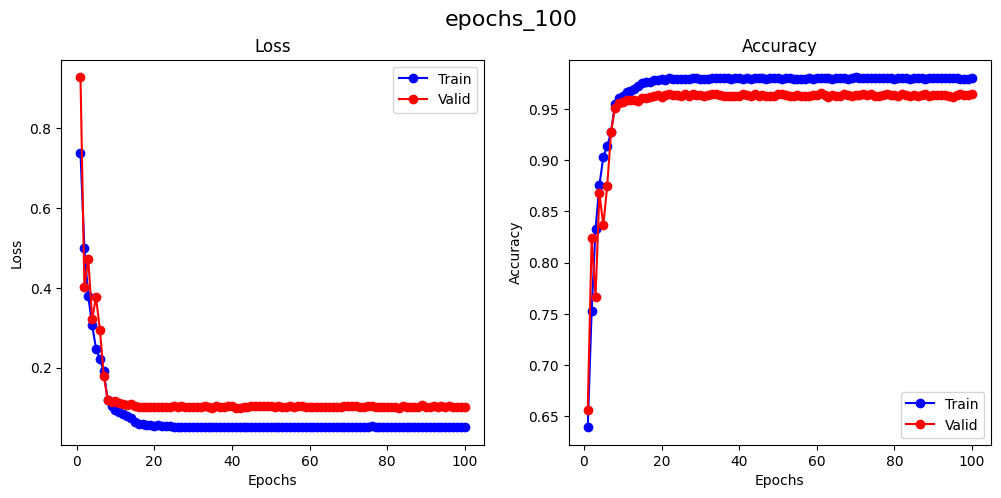

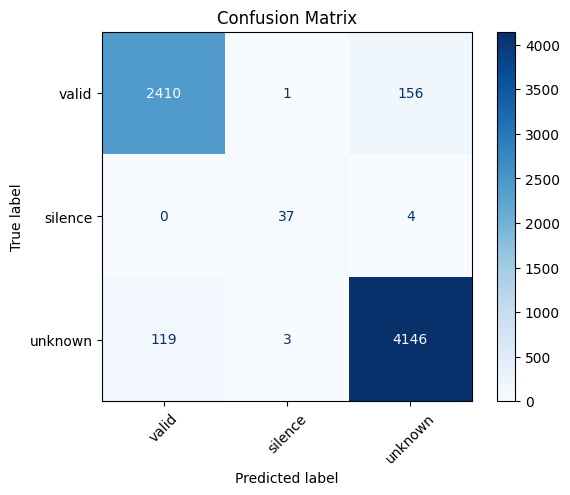

In [14]:
for config in experiment_configs:

    root_dir = os.path.join('experiments', f'{config['model_type']}_{config['model_name']}_vsu')
    os.makedirs(root_dir, exist_ok=True)
    
    all_train_acc_hist = []
    all_val_acc_hist = []
    all_train_loss_hist = []
    all_val_loss_hist = []
    run_accuracies = []

    for i in [42, 24, 62]:

        # Set random seed
        random_seed = i
        random.seed(random_seed)
        torch.manual_seed(random_seed)
        torch.cuda.manual_seed(random_seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        np.random.seed(random_seed)

        # Load data
        preprocessor = AudioPreprocessor()

        train_dataset = SpeechCommandsDataset(
            root_dir=config['data_dir'],
            file_list_path='train_list.txt',
            mode=config['model_type'],
            vsu=len(config['classes'])==3,
            preprocessor=preprocessor,
            augment=False
        )

        val_dataset = SpeechCommandsDataset(
            root_dir=config['data_dir'],
            file_list_path='validation_list.txt',
            mode=config['model_type'],
            vsu=len(config['classes'])==3,
            preprocessor=preprocessor,
            augment=False
        )

        test_dataset = SpeechCommandsDataset(
            root_dir=config['data_dir'],
            file_list_path='testing_list.txt',
            mode=config['model_type'],
            vsu=len(config['classes'])==3,
            preprocessor=preprocessor,
            augment=False
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=config['batch_size'],
            shuffle=True,
            num_workers=4
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=config['batch_size'],
            shuffle=False,
            num_workers=4
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=config['batch_size'],
            shuffle=True,
            num_workers=4
        )

        dataloaders = {
            'train': train_loader,
            'valid': val_loader,
            'test': test_loader
        }

        # Create model TODO others
        if config['model_type'] == '1d':
            if config['model_name'] == 'vgg':
                model = VGG1D(num_classes=len(config['classes']))
            elif config['model_name'] == 'resnet':
                model = ResNet1D(num_classes=len(config['classes']))
        else:  # '2d'
            model = get_2d_cnn(config['model_name'], num_classes=len(config['classes']))

        model = model.to(config['device'])

        # Train model
        criterion = nn.CrossEntropyLoss()

        optimizer = optim.Adam(model.parameters(), 
                            lr=config['learning_rate'], 
                            weight_decay=config['weight_decay'])
        scheduler = StepLR(optimizer, step_size=7, gamma=0.1)

        trained_model, train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist = train_model(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            dataloaders=dataloaders,
            device=config['device'],
            num_epochs=config['num_epochs']
        )
        
        # Save best model and model details
        folder = os.path.join(os.path.join(root_dir, config['title'].replace('.', '_')), f'rs_{i}')
        os.makedirs(folder, exist_ok=True)

        torch.save(model.state_dict(), os.path.join(folder, 'best_model.pt'))
        
        # Save training history
        plot_training_history(train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist, config['title'], folder)
        
        # Test model
        test_acc = test_model(model, test_loader, config['device'], folder, config['classes'])
        
        run_accuracies.append(test_acc)
        all_train_acc_hist.append([acc.cpu().numpy() for acc in train_acc_hist])
        all_val_acc_hist.append([acc.cpu().numpy() for acc in val_acc_hist])
        all_train_loss_hist.append([loss for loss in train_loss_hist])
        all_val_loss_hist.append([loss for loss in val_loss_hist])
        
    # Save three runs summary
    
    # Calculate mean and std
    mean_acc = statistics.mean(run_accuracies)
    std_acc = statistics.stdev(run_accuracies)

    summary_file = os.path.join(root_dir, 'summary.xlsx')
    headers = ['Title', 'Batch Size', 'Learning Rate', 'Weight Decay', 'Epochs',
            'Run 1 Accuracy', 'Run 2 Accuracy', 'Run 3 Accuracy', 'Mean Accuracy', 'Std Accuracy']

    row = [
        config['title'],
        config['batch_size'],
        config['learning_rate'],
        config['weight_decay'],
        config['num_epochs'],
        *run_accuracies,
        mean_acc,
        std_acc
    ]

    # Write row to summary.xlsx
    if not os.path.exists(summary_file):
        wb = Workbook()
        ws = wb.active
        ws.append(headers)
    else:
        wb = load_workbook(summary_file)
        ws = wb.active

    ws.append(row)
    wb.save(summary_file)
    
    plot_combined_training_history(all_train_acc_hist, all_val_acc_hist, all_train_loss_hist, all_val_loss_hist,
                                   config['title'], os.path.join(root_dir, config['title'].replace('.', '_')))
    
    matplotlib.pyplot.close()



In [7]:
from torchsummary import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VGG1D()
model = model.to(device)

summary(model, (1, 16384))

sample_input = torch.randn(1, 1, 16384).to(device)
model.eval()
with torch.no_grad():
    output = model(sample_input)
print(output.shape)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1             [-1, 8, 16384]              80
       BatchNorm1d-2             [-1, 8, 16384]              16
              ReLU-3             [-1, 8, 16384]               0
         MaxPool1d-4              [-1, 8, 4096]               0
            Block1-5              [-1, 8, 4096]               0
            Conv1d-6             [-1, 16, 4096]           1,168
       BatchNorm1d-7             [-1, 16, 4096]              32
              ReLU-8             [-1, 16, 4096]               0
         MaxPool1d-9             [-1, 16, 1024]               0
           Block1-10             [-1, 16, 1024]               0
           Conv1d-11             [-1, 32, 1024]           4,640
      BatchNorm1d-12             [-1, 32, 1024]              64
             ReLU-13             [-1, 32, 1024]               0
           Conv1d-14             [-1, 3

In [8]:
model = ResNet1D()
model = model.to(device)

summary(model, (1, 16384))

sample_input = torch.randn(1, 1, 16384).to(device)
model.eval()
with torch.no_grad():
    output = model(sample_input)
print(output.shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1             [-1, 48, 4077]           3,888
       BatchNorm1d-2             [-1, 48, 4077]              96
              ReLU-3             [-1, 48, 4077]               0
         MaxPool1d-4             [-1, 48, 1019]               0
            Block1-5             [-1, 48, 1019]               0
            Conv1d-6            [-1, 192, 1019]           9,408
       BatchNorm1d-7            [-1, 192, 1019]             384
            Conv1d-8             [-1, 48, 1019]          20,784
       BatchNorm1d-9             [-1, 48, 1019]              96
             ReLU-10             [-1, 48, 1019]               0
           Conv1d-11             [-1, 48, 1019]          20,784
      BatchNorm1d-12             [-1, 48, 1019]              96
             ReLU-13             [-1, 48, 1019]               0
           Conv1d-14            [-1, 19